# Lingala Medical Triage — NLP Pipeline

**XLM-RoBERTa fine-tuning for 3-class triage classification**

| Label | Description |
|---|---|
| Emergency | Severe symptoms, urgent care needed |
| Moderate  | Non-critical but requires attention |
| Low       | Mild symptoms, routine care |

**Notebook structure:**
1. Stopwords
2. Data loading & splitting
3. Emergency sample augmentation
4. Model definitions (FineTunedXLMR + CrossLingualTriageTransfer)
5. Orchestrator (run_all_models)
6. Run pipeline
7. Inference demo

In [1]:
#!pip install streamlit
#!pip install stop_words
#!pip install gensim
#!pip install snscrape

import os
import pandas as pd
from datetime import date
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1D CNN package
import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import librosa
from keras.utils import to_categorical
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.layers import Embedding
from keras.layers import Conv1D, GlobalAveragePooling1D, MaxPooling1D
# import libarries for reading data, exploring and plotting
from imblearn.over_sampling import SMOTE
from collections import Counter
#from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
%matplotlib inline
# library for train test split
from sklearn.model_selection import train_test_split

# deep learning libraries for text pre-processing
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Modeling
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, GRU, GlobalAveragePooling1D, Flatten, Dense, Dropout, LSTM, SpatialDropout1D, Bidirectional

2026-03-25 07:11:36.438989: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 07:11:36.731202: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-25 07:11:38.628088: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from gensim.parsing.preprocessing import remove_stopwords
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier


import warnings
warnings.filterwarnings("ignore")

## Cell 1 — Lingala Stopwords

In [3]:
%%writefile lingala_stopwords.py
"""
lingala_stopwords.py
====================
A curated stopword list for Lingala (ln) NLP tasks.

There is no official Lingala stopword list in NLTK, spaCy, or any major NLP
library. This list was compiled from:
  - Lingala grammar references (Swarthmore LING073, FSI Basic Course)
  - "Loba Lingala" guide (Yocum, 2014)
  - Wikipedia Lingala grammar article
  - Linguistic analysis of the medical triage corpus used in this project

Organized by grammatical category so you can customize for your task.
For example, in medical NLP you may want to KEEP negation words like "te"
(not/no) since they change clinical meaning drastically.

Author: Generated for Lingala Medical Triage NLP project
"""

# ──────────────────────────────────────────────────────────────────────────────
# 1. SUBJECT PRONOUNS
# These are verbal prefixes that double as standalone pronouns.
# ──────────────────────────────────────────────────────────────────────────────
SUBJECT_PRONOUNS = {
    "na",    # I / me (1sg)
    "o",     # you (2sg)
    "a",     # he / she / it (3sg animate)
    "to",    # we (1pl)
    "bo",    # you (2pl)
    "ba",    # they (3pl animate)
    "e",     # it (3sg inanimate)
    "i",     # they (3pl inanimate)
}

# ──────────────────────────────────────────────────────────────────────────────
# 2. PERSONAL / POSSESSIVE PRONOUNS
# ──────────────────────────────────────────────────────────────────────────────
PERSONAL_PRONOUNS = {
    "ngai",   # I / me / my (emphatic 1sg)
    "nga",   # I / me / my (emphatic 1sg)
    "yo",     # you / your (emphatic 2sg)
    "ye",     # him / her / his / her (emphatic 3sg)
    "biso",   # us / our (1pl)
    "bino",   # you / your (2pl)
    "bango",  # them / their (3pl)
}

# ──────────────────────────────────────────────────────────────────────────────
# 3. DEMONSTRATIVE PRONOUNS
# ──────────────────────────────────────────────────────────────────────────────
DEMONSTRATIVES = {
    "oyo",    # this / these (proximal)
    "wana",   # that / those (distal)
    "kuna",   # that over there (remote)
    "awa",    # here
    "kuna",   # there
    "wapi",   # where (interrogative/relative)
}

# ──────────────────────────────────────────────────────────────────────────────
# 4. CORE PREPOSITIONS & PARTICLES
# na and ya are by far the most frequent words in Lingala text.
# ──────────────────────────────────────────────────────────────────────────────
PREPOSITIONS_PARTICLES = {
    "na",     # with / at / in / to / and (multi-purpose preposition)
    "ya",     # of / from / belonging to (genitive/connective particle)
    "pe",     # also / too / and
    "mpe",    # and / also / as well
    "to",     # or (conjunction)
    "po",     # for / because (colloquial)
    "pona",   # for / in order to
    "kati",   # in / inside / among
    "wuti",   # from / coming from
    "uta",    # from / since
    "tii",    # until / up to
    "ata",    # even / even if
    "lelo",   # today (frequently functions as temporal filler)
}

# ──────────────────────────────────────────────────────────────────────────────
# 5. COPULA & AUXILIARY VERBS (conjugated forms of kozala = to be/have)
# ──────────────────────────────────────────────────────────────────────────────
COPULA_AUXILIARY = {
    "nazali",  # I am / I have (1sg present)
    "ozali",   # you are / you have (2sg present)
    "azali",   # he/she is / has (3sg present)
    "tozali",  # we are / we have (1pl present)
    "bozali",  # you are / you have (2pl present)
    "bazali",  # they are / they have (3pl present)
    "ezali",   # it is / it has (inanimate present)
    # Equator region spoken Lingala
    "nadjali",  # I am / I have (1sg present)
    "odjali",   # you are / you have (2sg present)
    "adjali",   # he/she is / has (3sg present)
    "todjali",  # we are / we have (1pl present)
    "bodjali",  # you are / you have (2pl present)
    "badjali",  # they are / they have (3pl present)
    "edjali",   # it is / it has (inanimate present)
    "bidjali",   # it is / it has (inanimate present)
    # Other region spoken Lingala
    "nayali",  # I am / I have (1sg present)
    "oyali",   # you are / you have (2sg present)
    "ayali",   # he/she is / has (3sg present)
    "toyali",  # we are / we have (1pl present)
    "boyali",  # you are / you have (2pl present)
    "bayali",  # they are / they have (3pl present)
    "eyali",   # it is / it has (inanimate present)
    "biyali",   # it is / it has (inanimate present)
    # Other region spoken Lingala
    "naali",  # I am / I have (1sg present)
    "oali",   # you are / you have (2sg present)
    "aali",   # he/she is / has (3sg present)
    "toali",  # we are / we have (1pl present)
    "boali",  # you are / you have (2pl present)
    "baali",  # they are / they have (3pl present)
    "eali",   # it is / it has (inanimate present)
    "biali",   # it is / it has (inanimate present)
    # Contracted / colloquial forms (Kinshasa spoken Lingala)
    "naza",    # contracted: nazali
    "oza",     # contracted: ozali
    "aza",     # contracted: azali
    "toza",    # contracted: tozali
    "boza",    # contracted: bozali
    "baza",    # contracted: bazali
    # Contracted / colloquial forms (Kinshasa spoken Lingala)
    "nazo",    # contracted: nazali+ko
    "ozo",     # contracted: nazali+ko
    "azo",     # contracted: nazali+ko
    "tozo",    # contracted: nazali+ko
    "bozo",    # contracted: nazali+ko
    "bazo",    # contracted: nazali+ko
    # Contracted / colloquial forms (Kinshasa spoken Lingala)
    "nao",    # contracted: nazali+ko
    "oo",     # contracted: nazali+ko
    "ao",     # contracted: nazali+ko
    "too",    # contracted: nazali+ko
    "boo",    # contracted: nazali+ko
    "bao",    # contracted: nazali+ko
    # Past forms
    "nazalaki",
    "ozalaki",
    "azalaki",
    "tozalaki",
    "bozalaki",
    "bazalaki",
    "ezalaki",
}

# ──────────────────────────────────────────────────────────────────────────────
# 6. NEGATION
# ⚠️  WARNING: In medical / clinical NLP, negation words change meaning
# entirely (e.g., "nazali kokosola te" = "I am NOT coughing").
# Consider KEEPING these depending on your task.
# ──────────────────────────────────────────────────────────────────────────────
NEGATION = {
    "te",     # not / no (primary negation particle, always final)
    "ata te", # not at all / absolutely not
    "ata",    # even (used in negative constructions)
}

# ──────────────────────────────────────────────────────────────────────────────
# 7. QUESTION WORDS
# ──────────────────────────────────────────────────────────────────────────────
QUESTION_WORDS = {
    "nini",    # what
    "nani",    # who
    "wapi",    # where
    "ndenge",  # how
    "mpo",     # why (short form)
    "mpona",   # why / for what reason
    "ntango",  # when / time (can also be content word in medical context)
    "boni",    # how many / how
    "etuka",   # which (inanimate)
    "moto",    # which person / who (can be content word = "person/head")
}

# ──────────────────────────────────────────────────────────────────────────────
# 8. CONJUNCTIONS
# ──────────────────────────────────────────────────────────────────────────────
CONJUNCTIONS = {
    "mpe",     # and / also
    "kasi",    # but / however
    "soki",    # if / when (conditional)
    "tango",   # when / as (temporal)
    "ntango",  # when / at the time
    "ndenge",  # as / how / like
    "po",      # because (colloquial)
    "pamba",   # because / in vain (context-dependent)
    "kutu",    # moreover / even more so
    "lisusu",  # again / also / moreover
    "boye",    # so / thus / like that
    "yango",   # that / therefore / so (demonstrative/connective)
    "bongo",   # so / therefore (discourse connector)
    "kombo",   # namely / which is called
}

# ──────────────────────────────────────────────────────────────────────────────
# 9. ADVERBS OF DEGREE / FREQUENCY / TIME (high frequency, low content)
# ──────────────────────────────────────────────────────────────────────────────
ADVERBS = {
    "mingi",    # much / many / very / a lot
    "moke",     # little / few / slightly
    "makasi",   # strongly / hard / severely (⚠️ can be clinically relevant)
    "malamu",   # well / good / fine
    "mabe",     # badly / poorly
    "noki",     # quickly / soon
    "lɛlɔ",     # today
    "lobi",     # tomorrow / yesterday (context-dependent)
    "kala",     # long ago / for a long time
    "sik'oyo",  # now / at the moment
    "sikoyo",   # now (variant)
    "nanu",     # not yet / still
    "likoló",   # above / up / more
    "nse",      # below / down
    "mbala",    # time(s) / once (as in "mbala moko" = once)
    "moko",     # one / alone / same (also a numeral)
    "mibale",   # two
    "misato",   # three
    "mpenza",   # really / truly / very much
    "solo",     # really / truly (from French "seul"?)
    "awa",      # here
    "kuna",     # there
    "fulu",     # suddenly / at once
}

# ──────────────────────────────────────────────────────────────────────────────
# 10. COMMON DISCOURSE FILLERS & INTERJECTIONS
# ──────────────────────────────────────────────────────────────────────────────
DISCOURSE_FILLERS = {
    "ee",      # yes
    "iyo",     # yes
    "yango",   # that / it (discourse filler)
    "bongo",   # so / thus / OK
    "ah",      # interjection
    "eh",      # interjection / hesitation
    "hm",      # hesitation
    "yoka",    # listen! / hey!
    "tala",    # look! / see!
    "eee",     # filler / affirmation
    "oo",      # oh! (surprise/understanding)
    "ko",      # infinitive marker (when isolated, not part of a verb)
}

# ──────────────────────────────────────────────────────────────────────────────
# 11. COMMON VERB PREFIXES / INFINITIVE MARKER
# These are not standalone stopwords but useful for morphological stripping.
# ──────────────────────────────────────────────────────────────────────────────
VERB_PREFIXES = [
    "ko",    # infinitive prefix
    "na",    # 1sg conjugation prefix
    "o",     # 2sg conjugation prefix
    "a",     # 3sg conjugation prefix
    "to",    # 1pl conjugation prefix
    "bo",    # 2pl conjugation prefix
    "ba",    # 3pl conjugation prefix
    "e",     # inanimate 3sg prefix
    "bi",     # inanimate 3sg prefix

]

# ──────────────────────────────────────────────────────────────────────────────
# MASTER STOPWORD SET
# Combines all categories. Customize by removing categories you need.
# ──────────────────────────────────────────────────────────────────────────────
STOPWORDS_FULL = (
    SUBJECT_PRONOUNS
    | PERSONAL_PRONOUNS
    | DEMONSTRATIVES
    | PREPOSITIONS_PARTICLES
    | COPULA_AUXILIARY
    | NEGATION          # ⚠️ remove this line for medical NLP!
    | QUESTION_WORDS
    | CONJUNCTIONS
    | ADVERBS
    | DISCOURSE_FILLERS
)

# Safe version for MEDICAL / CLINICAL NLP:
# Keeps negation and severity adverbs which carry clinical meaning.
STOPWORDS_MEDICAL = (
    SUBJECT_PRONOUNS
    | PERSONAL_PRONOUNS
    | DEMONSTRATIVES
    | PREPOSITIONS_PARTICLES
    | COPULA_AUXILIARY
    # NEGATION excluded — "te" changes clinical meaning
    | QUESTION_WORDS
    | CONJUNCTIONS
    | (ADVERBS - {"makasi", "mingi", "moke", "mpenza", "malamu", "mabe"})
    | DISCOURSE_FILLERS
)


# ──────────────────────────────────────────────────────────────────────────────
# USAGE
# ──────────────────────────────────────────────────────────────────────────────
def remove_stopwords(text: str, stopwords: set = STOPWORDS_MEDICAL) -> str:
    """
    Remove stopwords from a Lingala string.
    Lowercases before comparison; preserves original casing in output.
    """
    tokens = text.split()
    return " ".join(t for t in tokens if t.lower() not in stopwords)


def tokenize_and_filter(text: str, stopwords: set = STOPWORDS_MEDICAL) -> list:
    """Returns a list of non-stopword tokens."""
    return [t for t in text.split() if t.lower() not in stopwords]


if __name__ == "__main__":
    print(f"Full stopword list:    {len(STOPWORDS_FULL)} words")
    print(f"Medical stopword list: {len(STOPWORDS_MEDICAL)} words")
    print()

    examples = [
        "Naali na nkanda moke mpe nazali kolɛmba",
        "Nzoto na ngai ezali kobɛta makasi mpe mpɛmɛ ekɔtaka te",
        "Mwana azali na fiɛvɛrɛ ya 41°C mpe azali komilinga",
        "nao yoka mokongo pasi makasi moko",

    ]

    print("── Example: Medical stopword removal ──")
    for ex in examples:
        filtered = remove_stopwords(ex, STOPWORDS_MEDICAL)
        print(f"  Original : {ex}")
        print(f"  Filtered : {filtered}")
        print()


Overwriting lingala_stopwords.py


## Cell 2 — Load & Split Dataset

> **Label mapping:** `severe` → Emergency, `moderate` → Moderate, `mild + urgency=yes` → Moderate, `mild` → Low

> Stratified 70 / 15 / 15 split.

In [4]:
import csv
from collections import Counter, defaultdict
import random

# ── Config ────────────────────────────────────────────────────────────────────
CSV_PATH     = "lingala_triage_final_616.csv"
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15
RANDOM_SEED  = 42

# ── Load CSV ──────────────────────────────────────────────────────────────────
# Label column is "urgency" with values: Low / Moderate / Emergency
samples = []
with open(CSV_PATH, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    for row in reader:
        text    = row["text"].strip()
        label   = row["urgency"].strip()   # Low / Moderate / Emergency
        if not text or label not in ("Low", "Moderate", "Emergency"):
            continue
        samples.append({"text": text, "label": label})

print(f"Loaded {len(samples)} samples")
print("Label distribution:", Counter(s["label"] for s in samples))

# ── Stratified split ──────────────────────────────────────────────────────────
random.seed(RANDOM_SEED)

by_label = defaultdict(list)
for s in samples:
    by_label[s["label"]].append(s)

train_samples, val_samples, test_samples = [], [], []

for label, items in by_label.items():
    random.shuffle(items)
    n       = len(items)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    train_samples += items[:n_train]
    val_samples   += items[n_train:n_train + n_val]
    test_samples  += items[n_train + n_val:]

random.shuffle(train_samples)
random.shuffle(val_samples)
random.shuffle(test_samples)

print(f"\nSplit sizes:")
print(f"  Train : {len(train_samples)}  {Counter(s['label'] for s in train_samples)}")
print(f"  Val   : {len(val_samples)}   {Counter(s['label'] for s in val_samples)}")
print(f"  Test  : {len(test_samples)}   {Counter(s['label'] for s in test_samples)}")

# ── Class weights (inverse frequency) ────────────────────────────────────────
label_order   = ["Emergency", "Moderate", "Low"]
label_counts  = Counter(s["label"] for s in train_samples)
total         = sum(label_counts.values())
class_weights = [
    round(total / (len(label_order) * label_counts[l]), 4)
    if label_counts.get(l, 0) > 0 else 0.0
    for l in label_order
]
print(f"\nAuto class weights {label_order}: {class_weights}")

# ── French data (Stage 1 of Model 3) ─────────────────────────────────────────
french_train = [
    {"text": "Douleur thoracique intense et dyspnée sévère, patient inconscient.",   "label": "Emergency"},
    {"text": "Enfant cyanosé, ne répond plus normalement.",                           "label": "Emergency"},
    {"text": "Saignement abondant incontrôlable après accident.",                     "label": "Emergency"},
    {"text": "Fièvre modérée depuis 48h avec fatigue intense.",                       "label": "Moderate"},
    {"text": "Douleur abdominale modérée et nausées depuis ce matin.",                "label": "Moderate"},
    {"text": "Toux persistante depuis une semaine, légère fièvre.",                   "label": "Moderate"},
    {"text": "Légère céphalée sans autre symptôme.",                                  "label": "Low"},
    {"text": "Toux légère, pas de fièvre, pas de difficultés respiratoires.",         "label": "Low"},
    {"text": "Légère fatigue, mange et dort normalement.",                            "label": "Low"},
] * 12   # 108 French samples

french_val = [
    {"text": "Convulsions et perte de conscience soudaine.",    "label": "Emergency"},
    {"text": "Vomissements répétés avec déshydratation.",       "label": "Moderate"},
    {"text": "Rhume léger sans complications.",                 "label": "Low"},
] * 4    # 12 French val samples

print(f"\nFrench data: {len(french_train)} train / {len(french_val)} val")
print("Ready — run the next cell to start training.")

# ── Stopword preview ──────────────────────────────────────────────────────────
from lingala_stopwords import remove_stopwords, tokenize_and_filter, STOPWORDS_MEDICAL

print("\n── Stopword removal preview (STOPWORDS_MEDICAL) ──")
print("  Note: XLM-R uses raw text — this is for EDA/classical models only\n")
for s in train_samples[:4]:
    raw      = s["text"]
    filtered = remove_stopwords(raw, STOPWORDS_MEDICAL)
    tokens   = tokenize_and_filter(raw, STOPWORDS_MEDICAL)
    print(f"  [{s['label']}]")
    print(f"  Raw     : {raw[:90]}...")
    print(f"  Filtered: {filtered[:90]}...")
    print(f"  Tokens  : {tokens[:10]}")
    print()


Loaded 616 samples
Label distribution: Counter({'Low': 450, 'Moderate': 107, 'Emergency': 59})

Split sizes:
  Train : 430  Counter({'Low': 315, 'Moderate': 74, 'Emergency': 41})
  Val   : 91   Counter({'Low': 67, 'Moderate': 16, 'Emergency': 8})
  Test  : 95   Counter({'Low': 68, 'Moderate': 17, 'Emergency': 10})

Auto class weights ['Emergency', 'Moderate', 'Low']: [3.4959, 1.9369, 0.455]

French data: 108 train / 12 val
Ready — run the next cell to start training.

── Stopword removal preview (STOPWORDS_MEDICAL) ──
  Note: XLM-R uses raw text — this is for EDA/classical models only

  [Low]
  Raw     : Nazali na mpasi moke pe nzoto ezali moto likolo ya kolya malamu te...
  Filtered: mpasi moke nzoto likolo kolya malamu te...
  Tokens  : ['mpasi', 'moke', 'nzoto', 'likolo', 'kolya', 'malamu', 'te']

  [Emergency]
  Raw     : Nzoto na nga ekómi bolɔtɔ nokinoki sima ya kolya pe mpema na nga ezali mabe...
  Filtered: Nzoto ekómi bolɔtɔ nokinoki sima kolya mpema mabe...
  Tokens  : ['Nzo

## Cell 3 — Augment Emergency Samples

Techniques: synonym swap (stopword-aware) · clause reorder · prefix injection · Claude API paraphrase

> **Output:** `train_samples_aug`, `class_weights`

In [5]:
import random
import re
import json
import csv
import os
from collections import Counter

# ── Load original Emergency samples ──────────────────────────────────────────
with open("lingala_triage_final_616.csv", encoding="utf-8-sig") as f:
    all_rows = list(csv.DictReader(f))

emergency_texts = [
    r["text"].strip()
    for r in all_rows
    if r["urgency"].strip() == "Emergency"
]
print(f"\nOriginal Emergency samples: {len(emergency_texts)}")

# Quick content-word preview
print("Sample content tokens after stopword removal:")
for ex in emergency_texts[:3]:
    tokens = tokenize_and_filter(ex, STOPWORDS_MEDICAL)
    print(f"  {tokens}")


# ── Quality filter ────────────────────────────────────────────────────────────
MIN_CONTENT_TOKENS = 3   # discard augmented samples below this threshold

def has_enough_content(text: str) -> bool:
    """Return True if text has >= MIN_CONTENT_TOKENS after stopword removal."""
    return len(tokenize_and_filter(text, STOPWORDS_MEDICAL)) >= MIN_CONTENT_TOKENS


# ── 1. Synonym substitution (stopword-aware) ─────────────────────────────────
# Only clinical/content words are swapped — stopwords are left untouched.
# This avoids creating semantically empty augmentations.
SYNONYMS = {
    # Severity / intensity
    "makasi":               ["mingi", "ya ndelo", "koleka ndelo", "ya nkanda"],
    "mpasi":                ["pasi", "mawa ya nzoto", "mpasi ya ndelo", "pasi monene"],
    "mingi":                ["makasi", "lisusu", "koleka", "mpenza"],
    "ekomi":                ["ekomaki", "ezali", "ebandi", "ekotaki"],
    # Deterioration
    "elengelemi lisusu te": ["elingaki lisusu te", "ekufi", "ebebisami", "etikali te"],
    "ekomi kobeba":         ["ekomaki kobeba", "ezali mabe", "ebandaki kobeba"],
    "nzoto ekufi":          ["nzoto elingaki", "nzoto ezali pasi", "nzoto ebebisami"],
    # Emotional/urgency
    "Nazali kolela":        ["Nakobanga mingi", "Nazali na bobangi", "Nazali na mawa"],
    "Mpasi ezali":          ["Mawa ya nzoto ezali", "Pasi ezali", "Mpasi monene ezali"],
    "Bobangi ekomi":        ["Nsomo ekomi", "Kobanga ekomi", "Mawa ekomi"],
    "Mawa ya nzoto ekomi":  ["Mpasi ya nzoto ekomi", "Bobangi ya nzoto ekomi"],
    "Nazali na mawa mingi": ["Nazali kobanga mingi", "Nzoto na ngai ezali na pasi"],
    # Body responses
    "kolumba":              ["kokweya", "kolobana", "kovirika"],
    "kobeta motema":        ["kokangama motema", "motema kobeta nokinoki"],
    "kopema":               ["kozwa mpema", "kobeta souffle"],
    # Help-seeking
    "nalingi lisungi":      ["nalingi lisaidi", "nazali kotela lisungi", "nasengi lisungi"],
    "nalingi lisalisi":      ["nalingi lisungi", "nasengi lisalisi", "nazali kotela lisalisi"],
    "nakoka lisusu te":     ["nakoki lisusu te", "nzoto elingaka lisusu te", "nazali na makasi te"],
}

# Ensure no synonym key is a stopword (would never match in content)
_stopword_keys = [k for k in SYNONYMS if k.lower() in STOPWORDS_MEDICAL]
if _stopword_keys:
    print(f"  ⚠ Synonym keys that are stopwords (will rarely match): {_stopword_keys}")

def synonym_substitution(text: str, n_swaps: int = 2) -> str:
    """
    Swap up to n_swaps clinical phrases with synonyms.
    Skips any token that is a pure stopword.
    """
    keys = list(SYNONYMS.keys())
    random.shuffle(keys)
    result  = text
    swapped = 0
    for key in keys:
        if swapped >= n_swaps:
            break
        # Only swap if key is a content phrase (not a pure stopword)
        if key.lower() in STOPWORDS_MEDICAL:
            continue
        if key.lower() in result.lower():
            replacement = random.choice(SYNONYMS[key])
            result  = re.sub(re.escape(key), replacement, result, count=1, flags=re.IGNORECASE)
            swapped += 1
    return result


# ── 2. Sentence reordering ────────────────────────────────────────────────────
def reorder_sentences(text: str) -> str:
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    if len(parts) >= 2:
        parts[0], parts[1] = parts[1], parts[0]
    return " ".join(parts)


# ── 3. Prefix injection ───────────────────────────────────────────────────────
URGENT_PREFIXES = [
    "Nasengi lisungi ya mbala moko pamba te",
    "Nsomo na ngai ekomi makasi koleka",
    "Nzoto na ngai ezali kokweya, nalingi lisungi",
    "Situation na ngai ezali ya likama",
    "Nakosepela soki ozali kosalisa ngai mbala moko",
    "Nazali kofanda malamu te",
    "nalingi lisungi ya mbango",
    "Mpasi ezali koleka ndelo",
    "tosungami",
    "Tango ezali kokufa",
    "nalingi mosungi",
]

def inject_prefix(text: str) -> str:
    return f"{random.choice(URGENT_PREFIXES)}. {text}"


# ── 4. Claude API paraphrase ──────────────────────────────────────────────────
def paraphrase_with_claude_sync(texts, n_per_text=2):
    import requests
    results    = []
    batch_size = 5

    for i in range(0, len(texts), batch_size):
        batch    = texts[i:i+batch_size]
        numbered = "\n".join(f"{j+1}. {t}" for j, t in enumerate(batch))
        prompt   = (
            "Tu es un expert en langue Lingala et en terminologie médicale d'urgence.\n\n"
            f"Voici {len(batch)} phrases de patients en Lingala décrivant des symptômes d'urgence médicale.\n\n"
            f"Pour chaque phrase, génère exactement {n_per_text} paraphrases en Lingala qui :\n"
            "- Conservent le sens d'urgence médicale\n"
            "- Utilisent des mots différents mais restent naturelles en Lingala\n"
            "- Gardent le registre de patient qui souffre\n\n"
            "Réponds UNIQUEMENT en JSON valide, sans markdown ni backticks, format :\n"
            '{"1": ["paraphrase_a", "paraphrase_b"], "2": ["paraphrase_a", "paraphrase_b"]}\n\n'
            f"Phrases :\n{numbered}"
        )
        try:
            resp = requests.post(
                "https://api.anthropic.com/v1/messages",
                headers={
                    "Content-Type": "application/json",
                    "X-API-Key": os.environ.get("ANTHROPIC_API_KEY") # Use environment variable
                },
                json={
                    "model":      "claude-sonnet-4-20250514",
                    "max_tokens": 1500,
                    "messages":   [{"role": "user", "content": prompt}],
                },
                timeout=60,
            )
            resp.raise_for_status()
            raw  = re.sub(r"^```json\s*|```$", "", resp.json()["content"][0]["text"].strip(), flags=re.MULTILINE).strip()
            data = json.loads(raw)
            for key in sorted(data.keys(), key=lambda x: int(x)):
                results.extend(data[key])
            print(f"  ✓ Batch {i//batch_size+1}: {len(batch)} texts → {sum(len(v) for v in data.values())} paraphrases")
        except Exception as e:
            print(f"  ✗ Batch {i//batch_size+1} failed ({e}) — synonym fallback")
            for t in batch:
                results.extend([synonym_substitution(t) for _ in range(n_per_text)])
    return results


# ── Run augmentation ──────────────────────────────────────────────────────────
print("\nAugmenting Emergency samples...")
augmented_emergency = []

for text in emergency_texts:
    augmented_emergency.append(synonym_substitution(text, n_swaps=1))
    augmented_emergency.append(synonym_substitution(text, n_swaps=2))
    augmented_emergency.append(reorder_sentences(text))
    augmented_emergency.append(inject_prefix(text))

print(f"  Rule-based: +{len(augmented_emergency)} samples")

print("  Calling Claude API for paraphrases (2 per original)...")
claude_paraphrases = paraphrase_with_claude_sync(emergency_texts, n_per_text=2)
augmented_emergency.extend(claude_paraphrases)
print(f"  Claude paraphrases: +{len(claude_paraphrases)} samples")

# ── Deduplicate ───────────────────────────────────────────────────────────────
seen   = set()
deduped = []
for t in augmented_emergency:
    if t not in seen:
        seen.add(t)
        deduped.append(t)
print(f"  After dedup: {len(deduped)} samples")

# ── Quality filter (stopword-aware) ──────────────────────────────────────────
before_filter = len(deduped)
deduped = [t for t in deduped if has_enough_content(t)]
removed = before_filter - len(deduped)
print(f"  After quality filter (<{MIN_CONTENT_TOKENS} content tokens removed): "
      f"{len(deduped)} samples  [{removed} discarded]")

augmented_emergency = deduped
augmented_samples   = [{"text": t, "label": "Emergency"} for t in augmented_emergency]

# ── Rebuild augmented train split ─────────────────────────────────────────────
# train_samples must already be defined from cell_load_dataset
orig_emergency_train = [s for s in train_samples if s["label"] == "Emergency"]
non_emergency_train  = [s for s in train_samples if s["label"] != "Emergency"]

train_samples_aug = non_emergency_train + orig_emergency_train + augmented_samples
random.shuffle(train_samples_aug)

print(f"\nFinal augmented train set: {len(train_samples_aug)} samples")
print("Distribution:", Counter(s["label"] for s in train_samples_aug))

# ── Recompute class weights from augmented distribution ───────────────────────
label_order   = ["Emergency", "Moderate", "Low"]
label_counts  = Counter(s["label"] for s in train_samples_aug)
total         = sum(label_counts.values())
class_weights = []
for l in label_order:
    count = label_counts.get(l, 0)
    if count == 0:
        class_weights.append(0.0) # Assign 0 weight if no samples for this class
    else:
        class_weights.append(round(total / (len(label_order) * count), 4))
print(f"\nUpdated class weights {label_order}: {class_weights}")
print("\nVal/Test sets UNCHANGED (no augmentation on val/test).")
print(f"  Val  : {len(val_samples)}  {Counter(s['label'] for s in val_samples)}")
print(f"  Test : {len(test_samples)}  {Counter(s['label'] for s in test_samples)}")

# ── Save augmented train to disk ──────────────────────────────────────────────
os.makedirs("./results", exist_ok=True)
with open("./results/augmented_train.json", "w", encoding="utf-8") as f:
    json.dump(train_samples_aug, f, ensure_ascii=False, indent=2)
print("\nSaved \u2192 ./results/augmented_train.json")
print("Use `train_samples_aug` and `class_weights` when calling run_all_models().")


Original Emergency samples: 59
Sample content tokens after stopword removal:
  ['Makila', 'mingi', 'kobima', 'libumu', 'nga,', 'kolemba']
  ['mpasi', 'ntolo', 'ekómi', 'banda', 'kobeta', 'kokende']
  ['Mwana', 'mpema', 'te', 'elongi', 'kobongola']

Augmenting Emergency samples...
  Rule-based: +236 samples
  Calling Claude API for paraphrases (2 per original)...
  ✗ Batch 1 failed (401 Client Error: Unauthorized for url: https://api.anthropic.com/v1/messages) — synonym fallback
  ✗ Batch 2 failed (401 Client Error: Unauthorized for url: https://api.anthropic.com/v1/messages) — synonym fallback
  ✗ Batch 3 failed (401 Client Error: Unauthorized for url: https://api.anthropic.com/v1/messages) — synonym fallback
  ✗ Batch 4 failed (401 Client Error: Unauthorized for url: https://api.anthropic.com/v1/messages) — synonym fallback
  ✗ Batch 5 failed (401 Client Error: Unauthorized for url: https://api.anthropic.com/v1/messages) — synonym fallback
  ✗ Batch 6 failed (401 Client Error: Unauth

## Cell 4a — FineTunedXLMR

Direct Lingala fine-tuning on `xlm-roberta-base`.

In [6]:
"""
Fix for: TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

Cause:  transformers >= 4.41.0 renamed:
          evaluation_strategy  ->  eval_strategy
          (save_strategy stays the same but eval_strategy is the new name)

Drop-in replacement for Cell In[10] — replace only the TrainingArguments block.
Everything else (TriageDataset, FineTunedXLMR, _WeightedTrainer) stays identical.
"""

import os
import torch
import logging
import numpy as np
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EvalPrediction,
)
from sklearn.metrics import f1_score, recall_score, classification_report

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

LABEL2ID = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}


# ── Dataset ───────────────────────────────────────────────────────────────────

class TriageDataset(Dataset):
    def __init__(self, samples, tokenizer, max_length=128):
        self.encodings = tokenizer(
            [s["text"] for s in samples],
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(
            [LABEL2ID[s["label"]] for s in samples], dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }


# ── Weighted Trainer (for class imbalance) ────────────────────────────────────

class _WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if self.class_weights is not None:
            weight = torch.tensor(
                self.class_weights, dtype=torch.float
            ).to(logits.device)
            loss_fn = torch.nn.CrossEntropyLoss(weight=weight)
        else:
            loss_fn = torch.nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


# ── Metrics ───────────────────────────────────────────────────────────────────

def compute_metrics(p: EvalPrediction):
    preds  = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    macro_f1         = f1_score(labels, preds, average="macro",  zero_division=0)
    emergency_recall = recall_score(labels, preds, labels=[0], average="micro", zero_division=0)
    return {
        "macro_f1":         macro_f1,
        "emergency_recall": emergency_recall,
    }


# ── Main model class ──────────────────────────────────────────────────────────

class FineTunedXLMR:
    def __init__(
        self,
        model_name:    str   = "xlm-roberta-base",
        learning_rate: float = 2e-5,
        batch_size:    int   = 16,
        num_epochs:    int   = 5,
        max_length:    int   = 128,
        weight_decay:  float = 0.01,
        warmup_steps:  int   = 0,    # set >0 to override warmup_ratio (e.g. 100)
        fp16:          bool  = False,
        seed:          int   = 42,
        output_dir:    str   = "./xlmr_triage_output",
    ):
        self.model_name    = model_name
        self.learning_rate = learning_rate
        self.batch_size    = batch_size
        self.num_epochs    = num_epochs
        self.max_length    = max_length
        self.weight_decay  = weight_decay
        self.warmup_steps  = warmup_steps
        self.fp16          = fp16
        self.seed          = seed
        self.output_dir    = output_dir

        logger.info(f"Loading tokenizer from {model_name}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        logger.info(f"Loading model from {model_name}")
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            ignore_mismatched_sizes=True,
        )
        device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model.to(device)
        logger.info(f"FineTunedXLMR ready | device={device}")

    def train(self, train_samples, val_samples, class_weights=None):

        train_dataset = TriageDataset(train_samples, self.tokenizer, self.max_length)
        val_dataset   = TriageDataset(val_samples,   self.tokenizer, self.max_length)

        # ── Detect transformers version to use correct argument name ──────────
        import transformers as _tf
        _ver = tuple(int(x) for x in _tf.__version__.split(".")[:2])
        # >= 4.41 uses eval_strategy; older uses evaluation_strategy
        eval_strat_key = "eval_strategy" if _ver >= (4, 41) else "evaluation_strategy"

        training_args = TrainingArguments(
            output_dir=self.output_dir,
            # ── Hyperparameters ───────────────────────────────────────────────
            learning_rate=self.learning_rate,
            per_device_train_batch_size=self.batch_size,
            per_device_eval_batch_size=self.batch_size,
            num_train_epochs=self.num_epochs,
            # ── Regularisation ────────────────────────────────────────────────
            weight_decay=self.weight_decay,
            warmup_steps=self.warmup_steps,
            lr_scheduler_type="linear",
            # ── Evaluation & saving ───────────────────────────────────────────
            **{eval_strat_key: "epoch"},   # ← dynamic key: the only change needed
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            # ── Logging ───────────────────────────────────────────────────────
            logging_steps=50,
            report_to="none",
            # ── Hardware ──────────────────────────────────────────────────────
            fp16=self.fp16,
            seed=self.seed,
            dataloader_num_workers=0,   # 0 is safer on Windows/macOS
        )

        trainer_class = _WeightedTrainer if class_weights else Trainer

        trainer = trainer_class(
            model=self.model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            compute_metrics=compute_metrics,
            **({"class_weights": class_weights} if class_weights else {}),
        )

        logger.info("Starting training...")
        trainer.train()
        logger.info("Training complete.")

    def evaluate(self, test_samples):
        test_dataset = TriageDataset(test_samples, self.tokenizer, self.max_length)
        device = next(self.model.parameters()).device
        self.model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for i in range(len(test_dataset)):
                item = test_dataset[i]
                input_ids      = item["input_ids"].unsqueeze(0).to(device)
                attention_mask = item["attention_mask"].unsqueeze(0).to(device)
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                pred = torch.argmax(outputs.logits, dim=1).item()
                all_preds.append(pred)
                all_labels.append(item["labels"].item())

        macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        emergency_recall = recall_score(
            all_labels, all_preds, labels=[0], average="micro", zero_division=0
        )
        n_emergency = all_labels.count(0)
        critical_errors = sum(
            1 for t, p in zip(all_labels, all_preds) if t == 0 and p == 2
        )
        critical_error_rate = critical_errors / n_emergency if n_emergency > 0 else 0.0

        print("\n" + classification_report(
            all_labels, all_preds,
            target_names=["Emergency", "Moderate", "Low"],
            zero_division=0,
        ))
        return {
            "macro_f1":           macro_f1,
            "emergency_recall":   emergency_recall,
            "critical_error_rate": critical_error_rate,
            "predictions":        [ID2LABEL[p] for p in all_preds],
        }

    def predict(self, text: str) -> dict:
        self.model.eval()
        device = next(self.model.parameters()).device
        enc = self.tokenizer(
            text, truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        with torch.no_grad():
            logits = self.model(
                input_ids=enc["input_ids"].to(device),
                attention_mask=enc["attention_mask"].to(device),
            ).logits
        probs = torch.softmax(logits, dim=1).squeeze().tolist()
        pred_id = int(torch.argmax(logits, dim=1).item())
        return {
            "label":         ID2LABEL[pred_id],
            "confidence":    probs[pred_id],
            "probabilities": {ID2LABEL[i]: round(p, 4) for i, p in enumerate(probs)},
        }

    def save(self, path: str):
        self.model.save_pretrained(path)
        self.tokenizer.save_pretrained(path)
        logger.info(f"Model saved to {path}")

    @classmethod
    def load(cls, path: str, **kwargs):
        obj = cls.__new__(cls)
        obj.tokenizer = AutoTokenizer.from_pretrained(path)
        obj.model     = AutoModelForSequenceClassification.from_pretrained(path)
        device = "cuda" if torch.cuda.is_available() else "cpu"
        obj.model.to(device)
        logger.info(f"Model loaded from {path} | device={device}")
        return obj

## Cell 4b — CrossLingualTriageTransfer

Two-stage transfer: **Stage 1** French fine-tuning → **Stage 2** Lingala adaptation.

In [7]:
"""
Cross-lingual triage transfer: French → Lingala
XLM-RoBERTa fine-tuning in two stages.
Fixed for transformers >= 4.41
"""

import os
import torch
import logging
import numpy as np
from typing import Optional
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EvalPrediction,
)
from sklearn.metrics import (
    f1_score, recall_score, accuracy_score,
    classification_report, confusion_matrix as sk_cm,
)

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

LABEL2ID = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}


# ── Dataset ───────────────────────────────────────────────────────────────────

class TriageDataset(Dataset):
    def __init__(self, samples, tokenizer, max_length=128):
        self.encodings = tokenizer(
            [s["text"] for s in samples],
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(
            [LABEL2ID[s["label"]] for s in samples], dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }


# ── Weighted Trainer ──────────────────────────────────────────────────────────

class _WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        if self.class_weights is not None:
            weight = torch.tensor(self.class_weights, dtype=torch.float).to(logits.device)
            loss   = torch.nn.CrossEntropyLoss(weight=weight)(logits, labels)
        else:
            loss   = torch.nn.CrossEntropyLoss()(logits, labels)
        return (loss, outputs) if return_outputs else loss


# ── Metrics ───────────────────────────────────────────────────────────────────

def compute_metrics(p: EvalPrediction):
    preds  = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    return {
        "macro_f1":         f1_score(labels, preds, average="macro",  zero_division=0),
        "emergency_recall": recall_score(labels, preds, labels=[0], average="micro", zero_division=0),
    }


# ── Helper: build TrainingArguments safely ────────────────────────────────────

def _make_training_args(output_dir, learning_rate, batch_size,
                        num_epochs, weight_decay, warmup_steps,
                        fp16, seed):
    return TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=weight_decay,
        warmup_steps=warmup_steps,
        lr_scheduler_type="linear",
        eval_strategy="epoch",          # transformers >= 4.41
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        fp16=fp16,
        seed=seed,
        dataloader_num_workers=0,
        label_names=["labels"],
    )


# ── Main class ────────────────────────────────────────────────────────────────

class CrossLingualTriageTransfer:
    def __init__(
        self,
        model_name:            str   = "xlm-roberta-base",
        stage1_learning_rate:  float = 2e-5,
        stage1_batch_size:     int   = 16,
        stage1_epochs:         int   = 5,
        stage2_learning_rate:  float = 1e-5,
        stage2_batch_size:     int   = 16,
        stage2_epochs:         int   = 3,
        max_length:            int   = 128,
        weight_decay:          float = 0.01,
        warmup_steps:          int   = 0,
        fp16:                  bool  = False,
        seed:                  int   = 42,
        output_dir:            str   = "./xlmr_cross_lingual",
    ):
        self.stage1_learning_rate = stage1_learning_rate
        self.stage1_batch_size    = stage1_batch_size
        self.stage1_epochs        = stage1_epochs
        self.stage2_learning_rate = stage2_learning_rate
        self.stage2_batch_size    = stage2_batch_size
        self.stage2_epochs        = stage2_epochs
        self.max_length           = max_length
        self.weight_decay         = weight_decay
        self.warmup_steps         = warmup_steps
        self.fp16                 = fp16
        self.seed                 = seed
        self.output_dir           = output_dir
        self.stage1_complete      = False

        logger.info(f"Loading tokenizer from {model_name}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        logger.info(f"Loading base model from {model_name}")
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            ignore_mismatched_sizes=True,
        )
        device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model.to(device)
        logger.info(f"Model ready | device={device}")

    # ── internal trainer builder ──────────────────────────────────────────────

    def _build_trainer(
        self,
        stage:         int,
        output_subdir: str,
        learning_rate: float,
        batch_size:    int,
        num_epochs:    int,
        train_dataset: Dataset,
        eval_dataset:  Dataset,
        class_weights: Optional[list] = None,
    ) -> Trainer:

        args = _make_training_args(
            output_dir=output_subdir,
            learning_rate=learning_rate,
            batch_size=batch_size,
            num_epochs=num_epochs,
            weight_decay=self.weight_decay,
            warmup_steps=self.warmup_steps,
            fp16=self.fp16,
            seed=self.seed,
        )
        trainer_cls = _WeightedTrainer if class_weights else Trainer
        extra = {"class_weights": class_weights} if class_weights else {}
        return trainer_cls(
            model=self.model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            compute_metrics=compute_metrics,
            **extra,
        )

    # ── Stage 1: French fine-tuning ───────────────────────────────────────────

    def train_stage1_french(
        self,
        french_train:  list,
        french_val:    list,
        class_weights: Optional[list] = None,
    ):
        stage1_dir = os.path.join(self.output_dir, "stage1_french")
        logger.info(
            f"\n{'='*55}\nSTAGE 1: FRENCH FINE-TUNING\n"
            f"  Dataset : {len(french_train)} train / {len(french_val)} val\n"
            f"  LR      : {self.stage1_learning_rate}  Epochs: {self.stage1_epochs}\n"
            f"{'='*55}"
        )
        train_ds = TriageDataset(french_train, self.tokenizer, self.max_length)
        val_ds   = TriageDataset(french_val,   self.tokenizer, self.max_length)
        self.stage1_trainer = self._build_trainer(
            stage=1, output_subdir=stage1_dir,
            learning_rate=self.stage1_learning_rate,
            batch_size=self.stage1_batch_size,
            num_epochs=self.stage1_epochs,
            train_dataset=train_ds, eval_dataset=val_ds,
            class_weights=class_weights,
        )
        self.stage1_trainer.train()
        self.stage1_complete = True
        return self.stage1_trainer.state.log_history[-1] if self.stage1_trainer.state.log_history else {}

    # ── Stage 2: Lingala adaptation ───────────────────────────────────────────

    def train_stage2_lingala(
        self,
        lingala_train: list,
        lingala_val:   list,
        class_weights: Optional[list] = None,
    ):
        if not self.stage1_complete:
            logger.warning("Stage 1 not complete — running Stage 2 from base weights.")
        stage2_dir = os.path.join(self.output_dir, "stage2_lingala")
        logger.info(
            f"\n{'='*55}\nSTAGE 2: LINGALA ADAPTATION\n"
            f"  Dataset : {len(lingala_train)} train / {len(lingala_val)} val\n"
            f"  LR      : {self.stage2_learning_rate}  Epochs: {self.stage2_epochs}\n"
            f"{'='*55}"
        )
        train_ds = TriageDataset(lingala_train, self.tokenizer, self.max_length)
        val_ds   = TriageDataset(lingala_val,   self.tokenizer, self.max_length)
        self.stage2_trainer = self._build_trainer(
            stage=2, output_subdir=stage2_dir,
            learning_rate=self.stage2_learning_rate,
            batch_size=self.stage2_batch_size,
            num_epochs=self.stage2_epochs,
            train_dataset=train_ds, eval_dataset=val_ds,
            class_weights=class_weights,
        )
        self.stage2_trainer.train()
        return self.stage2_trainer.state.log_history[-1] if self.stage2_trainer.state.log_history else {}

    # ── Full pipeline ─────────────────────────────────────────────────────────

    def run_full_pipeline(
        self,
        french_train:   list,
        french_val:     list,
        lingala_train:  list,          # pass train_samples_aug here
        lingala_val:    list,
        class_weights:  Optional[list] = None,
    ) -> dict:
        s1 = self.train_stage1_french(french_train, french_val, class_weights)
        s2 = self.train_stage2_lingala(lingala_train, lingala_val, class_weights)
        return {"stage1": s1, "stage2": s2}

    # ── Evaluation (full metrics + confusion matrix) ──────────────────────────

    def evaluate_test(self, test_samples: list) -> dict:
        test_ds = TriageDataset(test_samples, self.tokenizer, self.max_length)
        device  = next(self.model.parameters()).device
        self.model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for i in range(len(test_ds)):
                item = test_ds[i]
                out  = self.model(
                    input_ids=item["input_ids"].unsqueeze(0).to(device),
                    attention_mask=item["attention_mask"].unsqueeze(0).to(device),
                )
                all_preds.append(int(torch.argmax(out.logits, dim=1)))
                all_labels.append(int(item["labels"]))

        macro_f1         = f1_score(all_labels, all_preds, average="macro",  zero_division=0)
        emergency_recall = recall_score(all_labels, all_preds, labels=[0], average="micro", zero_division=0)
        accuracy         = accuracy_score(all_labels, all_preds)
        n_emg            = all_labels.count(0)
        crit_err         = sum(1 for t, p in zip(all_labels, all_preds) if t == 0 and p == 2)
        cm               = sk_cm(all_labels, all_preds, labels=[0, 1, 2]).tolist()

        print("\n" + classification_report(
            all_labels, all_preds,
            target_names=["Emergency", "Moderate", "Low"],
            zero_division=0,
        ))
        return {
            "accuracy":            accuracy,
            "macro_f1":            macro_f1,
            "emergency_recall":    emergency_recall,
            "critical_error_rate": crit_err / n_emg if n_emg > 0 else 0.0,
            "confusion_matrix":    cm,
        }

    # ── Single prediction ─────────────────────────────────────────────────────

    def predict(self, text: str) -> dict:
        self.model.eval()
        device = next(self.model.parameters()).device
        enc = self.tokenizer(
            text, truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt",
        )
        with torch.no_grad():
            logits = self.model(
                input_ids=enc["input_ids"].to(device),
                attention_mask=enc["attention_mask"].to(device),
            ).logits
        probs   = torch.softmax(logits, dim=1).squeeze().tolist()
        pred_id = int(torch.argmax(logits, dim=1))
        return {
            "label":         ID2LABEL[pred_id],
            "confidence":    probs[pred_id],
            "probabilities": {ID2LABEL[i]: round(p, 4) for i, p in enumerate(probs)},
        }

    # ── Save / Load ───────────────────────────────────────────────────────────

    def save(self, path: str):
        self.model.save_pretrained(path)
        self.tokenizer.save_pretrained(path)
        logger.info(f"Model saved to {path}")

    @classmethod
    def load(cls, path: str, **kwargs) -> "CrossLingualTriageTransfer":
        obj           = cls.__new__(cls)
        obj.tokenizer = AutoTokenizer.from_pretrained(path)
        obj.model     = AutoModelForSequenceClassification.from_pretrained(path)
        device        = "cuda" if torch.cuda.is_available() else "cpu"
        obj.model.to(device)
        logger.info(f"Model loaded from {path} | device={device}")
        return obj

## Cell 4c — AfriBERTa fine-tuned

Direct Lingala fine-tuning on `AfriBERTa`.

In [8]:
import os
import torch
import logging
import numpy as np
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EvalPrediction,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    f1_score, recall_score, accuracy_score,
    classification_report, confusion_matrix
)

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

# ── Constants ──────────────────────────────────────────────────────────────────
AFRIBERTA_CHECKPOINT = "castorini/afriberta_large"
AFRIBERTA_MAX_LENGTH = 128

LABEL2ID_AFR = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL_AFR = {v: k for k, v in LABEL2ID_AFR.items()}


# ── Dataset ────────────────────────────────────────────────────────────────────
class AfriBERTaTriageDataset(Dataset):
    def __init__(self, samples, tokenizer, max_length=128):
        self.encodings = tokenizer(
            [s["text"] for s in samples],
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(
            [LABEL2ID_AFR[s["label"]] for s in samples], dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }


# ── Weighted Trainer ───────────────────────────────────────────────────────────
class _AfriBERTaWeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if self.class_weights is not None:
            weight = torch.tensor(
                self.class_weights, dtype=torch.float
            ).to(logits.device)
            loss_fn = torch.nn.CrossEntropyLoss(weight=weight)
        else:
            loss_fn = torch.nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


# ── Compute Metrics ────────────────────────────────────────────────────────────
def afriberta_compute_metrics(p: EvalPrediction):
    preds  = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    macro_f1         = f1_score(labels, preds, average="macro",  zero_division=0)
    emergency_recall = recall_score(labels, preds, labels=[0], average="micro", zero_division=0)
    return {
        "macro_f1":         macro_f1,
        "emergency_recall": emergency_recall,
    }


# ── Classifier ─────────────────────────────────────────────────────────────────
class AfriBERTaTriageClassifier:
    """
    Model 4: AfriBERTa-Large fine-tuned on Lingala triage.

    Key difference from Model 2 (XLM-R):
      AfriBERTa was pretrained exclusively on African language corpora,
      giving it better subword coverage for Bantu morphology.
      Swahili (in AfriBERTa's training data) shares verb extension patterns,
      noun class prefixes (m-/wa-, ki-/vi-, n-), and agglutinative structure
      with Lingala (mo-/ba-, e-/bi-, na-/nga-).
    """

    def __init__(
        self,
        output_dir:    str   = "./results/model4_afriberta",
        learning_rate: float = 3e-5,
        batch_size:    int   = 16,
        num_epochs:    int   = 5,
        max_length:    int   = AFRIBERTA_MAX_LENGTH,
        fp16:          bool  = False,          # ← False: no GPU on this machine
    ):
        self.output_dir    = output_dir
        self.learning_rate = learning_rate
        self.batch_size    = batch_size
        self.num_epochs    = num_epochs
        self.max_length    = max_length
        self.fp16          = fp16 and torch.cuda.is_available()  # safe guard

        print(f"Loading AfriBERTa tokenizer from {AFRIBERTA_CHECKPOINT}...")
        self.tokenizer = AutoTokenizer.from_pretrained(AFRIBERTA_CHECKPOINT)
        self.tokenizer.model_max_length = max_length

        print(f"Loading AfriBERTa model ({AFRIBERTA_CHECKPOINT})...")
        self.model = AutoModelForSequenceClassification.from_pretrained(
            AFRIBERTA_CHECKPOINT,
            num_labels=3,
            id2label=ID2LABEL_AFR,
            label2id=LABEL2ID_AFR,
        )
        print(f"  Parameters : ~126M")
        print(f"  Bantu langs: Swahili + Kinyarwanda (cross-lingual transfer to Lingala)")
        print(f"  Device     : {'GPU' if self.fp16 else 'CPU'}")

    def _make_training_args(self):
        """Standalone function — avoids TrainingArguments inside __init__."""
        return TrainingArguments(
            output_dir=self.output_dir,
            learning_rate=self.learning_rate,
            per_device_train_batch_size=self.batch_size,
            per_device_eval_batch_size=self.batch_size,
            num_train_epochs=self.num_epochs,
            weight_decay=0.01,
            warmup_steps=0,                    # ← replaces warmup_ratio
            lr_scheduler_type="linear",
            eval_strategy="epoch",             # ← replaces evaluation_strategy
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            logging_steps=50,
            report_to="none",
            fp16=self.fp16,
            dataloader_num_workers=0,          # ← avoids multiprocessing issues
            seed=42,
        )

    def train(self, train_samples, val_samples, class_weights=None):
        train_dataset = AfriBERTaTriageDataset(
            train_samples, self.tokenizer, self.max_length
        )
        val_dataset = AfriBERTaTriageDataset(
            val_samples, self.tokenizer, self.max_length
        )

        args = self._make_training_args()

        trainer_cls    = _AfriBERTaWeightedTrainer if class_weights else Trainer
        trainer_kwargs = dict(
            model=self.model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            processing_class=self.tokenizer,   # ← replaces deprecated `tokenizer=`
            compute_metrics=afriberta_compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        )
        if class_weights:
            trainer_kwargs["class_weights"] = class_weights

        self.trainer = trainer_cls(**trainer_kwargs)

        print(f"\n{'='*55}")
        print(f"TRAINING MODEL 4: AfriBERTa-Large")
        print(f"  Checkpoint : {AFRIBERTA_CHECKPOINT}")
        print(f"  Train size : {len(train_samples)}")
        print(f"  Val size   : {len(val_samples)}")
        print(f"  LR         : {self.learning_rate}")
        print(f"  Epochs     : {self.num_epochs}")
        print(f"{'='*55}")

        self.trainer.train()

    def evaluate(self, test_samples):
        test_dataset = AfriBERTaTriageDataset(
            test_samples, self.tokenizer, self.max_length
        )
        device = next(self.model.parameters()).device
        self.model.eval()

        all_preds, all_labels = [], []
        with torch.no_grad():
            for i in range(len(test_dataset)):
                item   = test_dataset[i]
                logits = self.model(
                    input_ids=item["input_ids"].unsqueeze(0).to(device),
                    attention_mask=item["attention_mask"].unsqueeze(0).to(device),
                ).logits
                all_preds.append(torch.argmax(logits, dim=1).item())
                all_labels.append(item["labels"].item())

        accuracy  = accuracy_score(all_labels, all_preds)
        macro_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        em_recall = recall_score(all_labels, all_preds, labels=[0],
                                 average="micro", zero_division=0)
        n_em      = all_labels.count(0)
        crit_err  = (
            sum(1 for t, p in zip(all_labels, all_preds) if t == 0 and p == 2) / n_em
            if n_em > 0 else 0.0
        )
        cm = confusion_matrix(all_labels, all_preds)

        print("\n" + classification_report(
            all_labels, all_preds,
            target_names=["Emergency", "Moderate", "Low"], zero_division=0
        ))
        return {
            "accuracy":            accuracy,
            "macro_f1":            macro_f1,
            "emergency_recall":    em_recall,
            "critical_error_rate": crit_err,
            "confusion_matrix":    cm.tolist(),
            "predictions":         [ID2LABEL_AFR[p] for p in all_preds],
        }

    def save(self, path):
        os.makedirs(path, exist_ok=True)
        self.model.save_pretrained(path)
        self.tokenizer.save_pretrained(path)
        print(f"AfriBERTa model saved → {path}")

    @classmethod
    def load(cls, path):
        obj            = cls.__new__(cls)
        obj.tokenizer  = AutoTokenizer.from_pretrained(path)
        obj.tokenizer.model_max_length = AFRIBERTA_MAX_LENGTH
        obj.model      = AutoModelForSequenceClassification.from_pretrained(path)
        obj.max_length = AFRIBERTA_MAX_LENGTH
        return obj

    def predict(self, text):
        self.model.eval()
        enc = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        device = next(self.model.parameters()).device
        with torch.no_grad():
            logits = self.model(
                input_ids=enc["input_ids"].to(device),
                attention_mask=enc["attention_mask"].to(device),
            ).logits
            probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        pred_id = int(np.argmax(probs))
        return {
            "label":         ID2LABEL_AFR[pred_id],
            "confidence":    round(float(probs[pred_id]), 4),
            "probabilities": {
                ID2LABEL_AFR[i]: round(float(p), 4)
                for i, p in enumerate(probs)
            },
        }

## Cell 5 — Orchestrator & Plotting

`run_all_models()` trains both models and returns a unified results dict.

In [9]:
import json, os, torch
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

LABELS = ["Low", "Moderate", "Emergency"]

# ─────────────────────────────────────────────────────────────────────────────
# Utility: Compute class weights (IMPORTANT FIX)
# ─────────────────────────────────────────────────────────────────────────────
def compute_class_weights(samples):
    counts = Counter([s["label"] for s in samples])
    total  = sum(counts.values())
    weights = {
        label: total / (len(counts) * counts[label])
        for label in counts
    }
    return [weights["Emergency"], weights["Moderate"], weights["Low"]]


# ─────────────────────────────────────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
def run_all_models(
    train_samples, val_samples, test_samples,
    french_train, french_val,
    run_zero_shot=False,
    openai_api_key=None,
    output_dir="./results",
):
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    results = {}

    # ✅ FIX: compute class weights once
    class_weights = compute_class_weights(train_samples)

    # ── Model 2: Fine-Tuned XLM-R ─────────────────────────────────────────────
    print("\n" + "="*55 + "\nRunning Model 2: Fine-Tuned XLM-R\n" + "="*55)
    m2 = FineTunedXLMR(
        learning_rate=2e-5, batch_size=16, num_epochs=5,
        fp16=torch.cuda.is_available(), output_dir=f"{output_dir}/model2",
    )
    m2.train(train_samples, val_samples, class_weights=class_weights)
    m2_metrics = m2.evaluate(test_samples)
    m2.save(f"{output_dir}/model2/final")

    results["model2_finetuned_xlmr"] = m2_metrics

    # ── Model 3: Cross-Lingual Transfer ───────────────────────────────────────
    print("\n" + "="*55 + "\nRunning Model 3: Cross-Lingual Transfer\n" + "="*55)
    m3 = CrossLingualTriageTransfer(
        stage1_learning_rate=2e-5, stage1_epochs=5,
        stage2_learning_rate=1e-5, stage2_epochs=3,
        fp16=torch.cuda.is_available(), output_dir=f"{output_dir}/model3",
    )
    m3.run_full_pipeline(
        french_train=french_train, french_val=french_val,
        lingala_train=train_samples, lingala_val=val_samples,
        class_weights=class_weights,
    )
    m3_metrics = m3.evaluate_test(test_samples)
    m3.save(f"{output_dir}/model3/final")

    results["model3_cross_lingual"] = m3_metrics

    # ── Model 4: Fine-Tuned AfriBERTa ─────────────────────────────────────────
    print("\n" + "="*55 + "\nRunning Model 4: Fine-Tuned AfriBERTa\n" + "="*55)
    try:
        m4 = AfriBERTaTriageClassifier(
            learning_rate=3e-5,
            batch_size=16,
            num_epochs=5,
            fp16=False,
            output_dir=f"{output_dir}/model4",
        )
        m4.train(train_samples, val_samples, class_weights=class_weights)
        m4_metrics = m4.evaluate(test_samples)
        m4.save(f"{output_dir}/model4/final")

        results["model4_fineTunedAfriBerta"] = m4_metrics
        print("Model 4 completed successfully.")

    except Exception as e:
        print(f"\nModel 4 skipped — {type(e).__name__}: {e}")


# ─────────────────────────────────────────────────────────────────────────────
# TABLE
# ─────────────────────────────────────────────────────────────────────────────
def print_comparison_table(results):
    header  = f"{'Model':<35} {'Accuracy':>10} {'Macro F1':>10} {'Emg Recall':>12} {'Crit Err':>10}"
    divider = "─" * len(header)
    print(f"\n{divider}\n{header}\n{divider}")

    model_names = {
        "model2_finetuned_xlmr":     "Model 2: Fine-Tuned XLM-R",
        "model3_cross_lingual":      "Model 3: Cross-Lingual Transfer",
        "model4_fineTunedAfriBerta": "Model 4: Fine-Tuned AfriBERTa",
    }

    for key, name in model_names.items():
        if key not in results:
            continue
        m = results[key]
        print(f"{name:<35} {m['accuracy']:>10.4f} {m['macro_f1']:>10.4f} "
              f"{m['emergency_recall']:>12.4f} {m['critical_error_rate']:>10.4f}")

    print(divider + "\n")


# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRICES
# ─────────────────────────────────────────────────────────────────────────────
def plot_confusion_matrices(results, output_dir="./results"):
    keys  = ["model2_finetuned_xlmr", "model3_cross_lingual",
             "model4_fineTunedAfriBerta"]

    names = ["Model 2: Fine-Tuned XLM-R",
             "Model 3: Cross-Lingual Transfer",
             "Model 4: Fine-Tuned AfriBERTa",
             ]

    cms = [
        np.array(results[k]["confusion_matrix"])
        for k in keys if k in results and results[k].get("confusion_matrix")
    ]

    present_names = [
        names[i] for i, k in enumerate(keys)
        if k in results and results[k].get("confusion_matrix")
    ]

    if not cms:
        print("No confusion matrices to plot.")
        return

    fig, axes = plt.subplots(1, len(cms), figsize=(6 * len(cms), 5))
    if len(cms) == 1:
        axes = [axes]

    for ax, cm, name in zip(axes, cms, present_names):
        disp = ConfusionMatrixDisplay(cm, display_labels=["Emergency", "Moderate", "Low"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name, fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"{output_dir}/confusion_matrices.png", dpi=150)
    print("Saved confusion matrices")


# ─────────────────────────────────────────────────────────────────────────────
# METRIC COMPARISON
# ─────────────────────────────────────────────────────────────────────────────
def plot_metric_comparison(results, output_dir="./results"):
    model_keys   = ["model2_finetuned_xlmr", "model3_cross_lingual",
                    "model4_fineTunedAfriBerta"]

    model_labels = ["XLM-R", "Cross-Lingual", "AfriBERTa"]

    metrics      = ["accuracy", "macro_f1", "emergency_recall", "critical_error_rate"]
    metric_names = ["Accuracy", "Macro F1", "Emergency Recall", "Critical Error Rate"]

    present = [(k, l) for k, l in zip(model_keys, model_labels) if k in results]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()

    for ax, metric, name in zip(axes, metrics, metric_names):
        vals = [results[k].get(metric, 0) for k, _ in present]
        labs = [l for _, l in present]

        ax.bar(labs, vals)
        ax.set_title(name)
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/metric_comparison.png", dpi=150)
    print("Saved metric comparison")

In [10]:
import json, os, torch
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

LABELS = ["Low", "Moderate", "Emergency"]

# ── Utility: Compute class weights ────────────────────────────────────────────
def compute_class_weights(samples):
    counts = Counter([s["label"] for s in samples])
    total  = sum(counts.values())
    weights = {
        label: total / (len(counts) * counts[label])
        for label in counts
    }
    return [weights["Emergency"], weights["Moderate"], weights["Low"]]


def run_all_models(
    train_samples, val_samples, test_samples,
    french_train, french_val,
    run_zero_shot=False,
    openai_api_key=None,
    output_dir="./results",
):
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    results = {}

    # ✅ FIX: compute class weights
    class_weights = compute_class_weights(train_samples)

    # ── Model 2: Fine-Tuned XLM-R ─────────────────────────────────────────────
    print("\n" + "="*55 + "\nRunning Model 2: Fine-Tuned XLM-R\n" + "="*55)
    m2 = FineTunedXLMR(
        learning_rate=2e-5, batch_size=16, num_epochs=5,
        fp16=torch.cuda.is_available(), output_dir=f"{output_dir}/model2",
    )
    m2.train(train_samples, val_samples, class_weights=class_weights)
    m2_metrics = m2.evaluate(test_samples)
    m2.save(f"{output_dir}/model2/final")
    results["model2_finetuned_xlmr"] = m2_metrics

    # ── Model 3: Cross-Lingual Transfer ───────────────────────────────────────
    print("\n" + "="*55 + "\nRunning Model 3: Cross-Lingual Transfer\n" + "="*55)
    m3 = CrossLingualTriageTransfer(
        stage1_learning_rate=2e-5, stage1_epochs=5,
        stage2_learning_rate=1e-5, stage2_epochs=3,
        fp16=torch.cuda.is_available(), output_dir=f"{output_dir}/model3",
    )
    m3.run_full_pipeline(
        french_train=french_train, french_val=french_val,
        lingala_train=train_samples, lingala_val=val_samples,
        class_weights=class_weights,
    )
    m3_metrics = m3.evaluate_test(test_samples)
    m3.save(f"{output_dir}/model3/final")
    results["model3_cross_lingual"] = m3_metrics

    # ── Model 4: Fine-Tuned AfriBERTa ─────────────────────────────────────────
    print("\n" + "="*55 + "\nRunning Model 4: Fine-Tuned AfriBERTa\n" + "="*55)
    try:
        m4 = AfriBERTaTriageClassifier(
            learning_rate=3e-5,
            batch_size=16,
            num_epochs=5,
            fp16=False,
            output_dir=f"{output_dir}/model4",
        )
        m4.train(train_samples, val_samples, class_weights=class_weights)
        m4_metrics = m4.evaluate(test_samples)
        m4.save(f"{output_dir}/model4/final")
        results["model4_fineTunedAfriBerta"] = m4_metrics
        print("Model 4 completed successfully.")
    except Exception as e:
        print(f"\nModel 4 skipped — {type(e).__name__}: {e}")


def print_comparison_table(results):
    header  = f"{'Model':<35} {'Accuracy':>10} {'Macro F1':>10} {'Emg Recall':>12} {'Crit Err':>10}"
    divider = "─" * len(header)
    print(f"\n{divider}\n{header}\n{divider}")

    model_names = {
        "model2_finetuned_xlmr":     "Model 2: Fine-Tuned XLM-R",
        "model3_cross_lingual":      "Model 3: Cross-Lingual Transfer",
        "model4_fineTunedAfriBerta": "Model 4: Fine-Tuned AfriBERTa",
    }

    for key, name in model_names.items():
        if key not in results:
            continue
        m = results[key]

        # ✅ SAFE ACCESS (fix KeyError)
        acc  = m.get("accuracy", 0)
        f1   = m.get("macro_f1", 0)
        rec  = m.get("emergency_recall", 0)
        err  = m.get("critical_error_rate", 0)

        print(f"{name:<35} {acc:>10.4f} {f1:>10.4f} "
              f"{rec:>12.4f} {err:>10.4f}")

    print(divider + "\n")


def plot_confusion_matrices(results, output_dir="./results"):
    keys  = ["model2_finetuned_xlmr", "model3_cross_lingual",
             "model4_fineTunedAfriBerta"]

    names = ["Model 2: Fine-Tuned XLM-R",
             "Model 3: Cross-Lingual Transfer",
             "Model 4: Fine-Tuned AfriBERTa",
             ]

    cms = [
        np.array(results[k]["confusion_matrix"])
        for k in keys
        if k in results and results[k].get("confusion_matrix")
    ]

    present_names = [
        names[i] for i, k in enumerate(keys)
        if k in results and results[k].get("confusion_matrix")
    ]

    if not cms:
        print("No confusion matrices to plot.")
        return

    fig, axes = plt.subplots(1, len(cms), figsize=(6 * len(cms), 5))
    if len(cms) == 1:
        axes = [axes]

    label_names = ["Emergency", "Moderate", "Low"]

    for ax, cm, name in zip(axes, cms, present_names):
        disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name, fontsize=12, fontweight="bold")

    plt.tight_layout()
    path = f"{output_dir}/confusion_matrices.png"
    plt.savefig(path, bbox_inches="tight", dpi=150)
    print(f"Saved: {path}")
    plt.show()


def plot_metric_comparison(results, output_dir="./results"):
    model_keys   = ["model2_finetuned_xlmr", "model3_cross_lingual",
                    "model4_fineTunedAfriBerta"]

    model_labels = ["Fine-Tuned XLM-R", "Cross-Lingual Transfer",
                    "Fine-Tuned AfriBERTa"]

    metrics      = ["accuracy", "macro_f1", "emergency_recall", "critical_error_rate"]
    metric_names = ["Accuracy", "Macro F1", "Emergency Recall", "Critical Error Rate (↓)"]
    colors       = ["#4A90D9", "#27AE60", "#E74C3C", "#F39C12"]

    present = [(k, l) for k, l in zip(model_keys, model_labels) if k in results]

    if not present:
        print("No results to plot.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, metric, mname, color in zip(axes, metrics, metric_names, colors):
        vals = [results[k].get(metric, 0) for k, _ in present]
        labs = [l for _, l in present]

        bars = ax.bar(labs, vals, color=color, alpha=0.85,
                      edgecolor="white", linewidth=1.2)

        ax.set_title(mname, fontsize=11, fontweight="bold")
        ax.set_ylim(0, 1.1)

        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle("Model Comparison — Lingala Medical Triage",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    path = f"{output_dir}/metric_comparison.png"
    plt.savefig(path, bbox_inches="tight", dpi=150)
    print(f"Saved: {path}")
    plt.show()

## Cell 6 — Run Full Pipeline

In [11]:
# ── Run full pipeline on real dataset ────────────────────────────────────────
results = run_all_models(
    train_samples=train_samples_aug,
    val_samples=val_samples,
    test_samples=test_samples,
    french_train=french_train,
    french_val=french_val,
    run_zero_shot=False,
    output_dir="./results",
)

# ── Report ────────────────────────────────────────────────────────────────────
print_comparison_table(results)
plot_confusion_matrices(results)
plot_metric_comparison(results)

# Save JSON (fixed)
os.makedirs("./results", exist_ok=True)

def convert(o):
    import numpy as np
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)

with open("./results/results.json", "w") as f:
    json.dump(results, f, indent=2, default=convert)

print("Results saved → ./results/results.json")

INFO:__main__:Loading tokenizer from xlm-roberta-base



Running Model 2: Fine-Tuned XLM-R


INFO:httpx:HTTP Request: HEAD https://huggingface.co/xlm-roberta-base/resolve/main/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/xlm-roberta-base/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/xlm-roberta-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/FacebookAI/xlm-roberta-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/xlm-roberta-base/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/FacebookAI/xlm-roberta-base/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/xlm-roberta-base "HTTP/1.1 307 Temporary R

Epoch,Training Loss,Validation Loss,Macro F1,Emergency Recall
1,No log,1.234718,0.282513,1.000000
2,1.088779,1.010397,0.497719,0.750000
3,0.967144,0.921689,0.570945,0.500000
4,0.827563,0.617957,0.610507,0.375000
5,0.645700,0.618550,0.644042,0.625000


Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  1.08it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'rober

...

Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  2.06it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'rober


              precision    recall  f1-score   support

   Emergency       0.83      1.00      0.91        10
    Moderate       1.00      0.88      0.94        17
         Low       1.00      1.00      1.00        68

    accuracy                           0.98        95
   macro avg       0.94      0.96      0.95        95
weighted avg       0.98      0.98      0.98        95



Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  1.92it/s]


AfriBERTa model saved → ./results/model4/final
Model 4 completed successfully.

─────────────────────────────────────────────────────────────────────────────────
Model                                 Accuracy   Macro F1   Emg Recall   Crit Err
─────────────────────────────────────────────────────────────────────────────────


TypeError: argument of type 'NoneType' is not iterable

In [ ]:
import json, os, torch
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, f1_score, recall_score,
                              classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize
from collections import Counter

LABELS = ["Low", "Moderate", "Emergency"]

def run_all_models(
    train_samples, val_samples, test_samples,
    french_train, french_val,
    run_zero_shot=False,
    openai_api_key=None,
    output_dir="./results",
):
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    results = {}

    # ── Model 2: Fine-Tuned XLM-R ─────────────────────────────────────────────
    print("\n" + "="*55 + "\nRunning Model 2: Fine-Tuned XLM-R\n" + "="*55)
    m2 = FineTunedXLMR(
        learning_rate=2e-5, batch_size=16, num_epochs=5,
        fp16=torch.cuda.is_available(), output_dir=f"{output_dir}/model2",
    )
    m2.train(train_samples_aug, val_samples, class_weights=class_weights)
    m2_metrics = m2.evaluate(test_samples)
    m2.save(f"{output_dir}/model2/final")
    results["model2_finetuned_xlmr"] = {
        "accuracy":            m2_metrics.get("accuracy", 0),
        "macro_f1":            m2_metrics.get("macro_f1", 0),
        "emergency_recall":    m2_metrics.get("emergency_recall", 0),
        "critical_error_rate": m2_metrics.get("critical_error_rate", 0),
        "confusion_matrix":    m2_metrics.get("confusion_matrix"),
    }

    # ── Model 3: Cross-Lingual Transfer ───────────────────────────────────────
    print("\n" + "="*55 + "\nRunning Model 3: Cross-Lingual Transfer\n" + "="*55)
    m3 = CrossLingualTriageTransfer(
        stage1_learning_rate=2e-5, stage1_epochs=5,
        stage2_learning_rate=1e-5, stage2_epochs=3,
        fp16=torch.cuda.is_available(), output_dir=f"{output_dir}/model3",
    )
    m3.run_full_pipeline(
        french_train=french_train, french_val=french_val,
        lingala_train=train_samples_aug, lingala_val=val_samples,
        class_weights=class_weights,
    )
    m3_metrics = m3.evaluate_test(test_samples)
    m3.save(f"{output_dir}/model3/final")
    results["model3_cross_lingual"] = {
        "accuracy":            m3_metrics.get("accuracy", 0),
        "macro_f1":            m3_metrics.get("macro_f1", 0),
        "emergency_recall":    m3_metrics.get("emergency_recall", 0),
        "critical_error_rate": m3_metrics.get("critical_error_rate", 0),
        "confusion_matrix":    m3_metrics.get("confusion_matrix"),
    }

    # ── Model 4: Fine-Tuned AfriBERTa ─────────────────────────────────────────
    print("\n" + "="*55 + "\nRunning Model 4: Fine-Tuned AfriBERTa\n" + "="*55)
    try:
        m4 = AfriBERTaTriageClassifier(
            learning_rate=3e-5,
            batch_size=16,
            num_epochs=5,
            fp16=False,
            output_dir=f"{output_dir}/model4",
        )
        m4.train(train_samples_aug, val_samples, class_weights=class_weights)
        m4_metrics = m4.evaluate(test_samples)
        m4.save(f"{output_dir}/model4/final")
        results["model4_fineTunedAfriBerta"] = {
            "accuracy":            m4_metrics.get("accuracy", 0),
            "macro_f1":            m4_metrics.get("macro_f1", 0),
            "emergency_recall":    m4_metrics.get("emergency_recall", 0),
            "critical_error_rate": m4_metrics.get("critical_error_rate", 0),
            "confusion_matrix":    m4_metrics.get("confusion_matrix"),
        }
        print("Model 4 completed successfully.")
    except Exception as e:
        print(f"\nModel 4 skipped — {type(e).__name__}: {e}")
        print("Tips:")
        print("  1. pip install sentencepiece protobuf --break-system-packages")
        print("  2. rm -rf ~/.cache/huggingface/hub/models--castorini--afriberta_large")
        print("  3. Restart kernel and re-run")

    
def print_comparison_table(results):
    header  = f"{'Model':<35} {'Accuracy':>10} {'Macro F1':>10} {'Emg Recall':>12} {'Crit Err':>10}"
    divider = "─" * len(header)
    print(f"\n{divider}\n{header}\n{divider}")
    model_names = {
        "model2_finetuned_xlmr":     "Model 2: Fine-Tuned XLM-R",
        "model3_cross_lingual":      "Model 3: Cross-Lingual Transfer",
        "model4_fineTunedAfriBerta": "Model 4: Fine-Tuned AfriBERTa",
        "model5_bilstm_attention":   "Model 5: BiLSTM + Attention",   # ← added
    }
    for key, name in model_names.items():
        if key not in results:
            continue
        m = results[key]
        print(f"{name:<35} {m['accuracy']:>10.4f} {m['macro_f1']:>10.4f} "
              f"{m['emergency_recall']:>12.4f} {m['critical_error_rate']:>10.4f}")
    print(divider + "\n")


def plot_confusion_matrices(results, output_dir="./results"):
    keys  = ["model2_finetuned_xlmr", "model3_cross_lingual",
             "model4_fineTunedAfriBerta", "model5_bilstm_attention"]   # ← added
    names = ["Model 2: Fine-Tuned XLM-R", "Model 3: Cross-Lingual Transfer",
             "Model 4: Fine-Tuned AfriBERTa", "Model 5: BiLSTM + Attention"]
    cms   = [
        np.array(results[k]["confusion_matrix"])
        for k in keys
        if k in results and results[k].get("confusion_matrix")
    ]
    present_names = [
        names[i] for i, k in enumerate(keys)
        if k in results and results[k].get("confusion_matrix")
    ]
    if not cms:
        print("No confusion matrices to plot.")
        return
    fig, axes = plt.subplots(1, len(cms), figsize=(6 * len(cms), 5))
    if len(cms) == 1:
        axes = [axes]
    label_names = ["Emergency", "Moderate", "Low"]
    for ax, cm, name in zip(axes, cms, present_names):
        disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name, fontsize=12, fontweight="bold")
    plt.suptitle("Confusion Matrices — Lingala Triage System", fontsize=14, y=1.02)
    plt.tight_layout()
    path = f"{output_dir}/confusion_matrices.png"
    plt.savefig(path, bbox_inches="tight", dpi=150)
    print(f"Saved: {path}")
    plt.show()


def plot_metric_comparison(results, output_dir="./results"):
    model_keys   = ["model2_finetuned_xlmr", "model3_cross_lingual",
                    "model4_fineTunedAfriBerta", "model5_bilstm_attention"]  # ← added
    model_labels = ["Fine-Tuned XLM-R", "Cross-Lingual Transfer",
                    "Fine-Tuned AfriBERTa", "BiLSTM + Attention"]
    metrics      = ["accuracy", "macro_f1", "emergency_recall", "critical_error_rate"]
    metric_names = ["Accuracy", "Macro F1", "Emergency Recall", "Critical Error Rate (↓)"]
    colors       = ["#4A90D9", "#27AE60", "#E74C3C", "#F39C12"]
    present = [(k, l) for k, l in zip(model_keys, model_labels) if k in results]
    if not present:
        print("No results to plot.")
        return
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    for ax, metric, mname, color in zip(axes, metrics, metric_names, colors):
        vals = [results[k].get(metric, 0) for k, _ in present]
        labs = [l for _, l in present]
        bars = ax.bar(labs, vals, color=color, alpha=0.85,
                      edgecolor="white", linewidth=1.2)
        ax.set_title

from transformers import AutoTokenizer

# Test which ID works
for model_id in [
    "castorini/afriberta_large",
    "castorini/afriberta_base",
    "Davlan/afriberta_large",
]:
    try:
        tok = AutoTokenizer.from_pretrained(model_id)
        print(f"✓ Works: {model_id}")
        break
    except Exception as e:
        print(f"✗ Failed: {model_id} — {type(e).__name__}")

In [ ]:
# ── Report from saved models (no retraining) ─────────────────────────────────
# Loads the already-trained models from disk and evaluates on the same test set.
# This preserves the 0.92 accuracy from the previous training run.

import torch, os, json
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

os.makedirs("./results", exist_ok=True)

LABEL2ID = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

def evaluate_saved_model(model_path, test_samples, max_length=128):
    """Load a saved model and evaluate on test_samples without retraining."""
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model     = AutoModelForSequenceClassification.from_pretrained(model_path)
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for s in test_samples:
            enc = tokenizer(
                s["text"], max_length=max_length,
                padding="max_length", truncation=True, return_tensors="pt"
            )
            logits = model(
                input_ids=enc["input_ids"].to(device),
                attention_mask=enc["attention_mask"].to(device)
            ).logits
            all_preds.append(torch.argmax(logits, dim=1).item())
            all_labels.append(LABEL2ID[s["label"]])

    accuracy   = accuracy_score(all_labels, all_preds)
    macro_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    em_recall  = recall_score(all_labels, all_preds, labels=[0],
                              average="micro", zero_division=0)
    n_em       = all_labels.count(0)
    crit_err   = sum(1 for t, p in zip(all_labels, all_preds)
                     if t == 0 and p == 2) / n_em if n_em > 0 else 0.0
    cm         = confusion_matrix(all_labels, all_preds).tolist()

    return {
        "accuracy":            accuracy,
        "macro_f1":            macro_f1,
        "emergency_recall":    em_recall,
        "critical_error_rate": crit_err,
        "confusion_matrix":    cm,
    }

results = {}

# ── Model 2: load from ./results/model2/final ────────────────────────────────
print("Evaluating Model 2 (Fine-Tuned XLM-R) from saved checkpoint...")
results["model2_finetuned_xlmr"] = evaluate_saved_model(
    "./results/model2/final", test_samples
)

# ── Model 3: load from ./results/model3/final ────────────────────────────────
print("Evaluating Model 3 (Cross-Lingual Transfer) from saved checkpoint...")
results["model3_cross_lingual"] = evaluate_saved_model(
    "./results/model3/final", test_samples
)

# ── Model 4: load from ./results/model4/final ────────────────────────────────
print("Evaluating Model 4 (Fine-Tuned AfriBERTa) from saved checkpoint...")
results["model4_fineTunedAfriBerta"] = evaluate_saved_model(
    "./results/model4/final", test_samples
)

# ── Report ────────────────────────────────────────────────────────────────────
print_comparison_table(results)
plot_confusion_matrices(results)
plot_metric_comparison(results)

with open("./results/results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=3, default=str)
print("Results saved → ./results/results.json")

In [ ]:
import torch, os, json
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

os.makedirs("./results", exist_ok=True)

LABEL2ID = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

# ── Evaluator for HuggingFace models (M2, M3, M4) ────────────────────────────
def evaluate_saved_model(model_path, test_samples, max_length=128):
    """Load a HuggingFace saved model and evaluate on test_samples."""
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model     = AutoModelForSequenceClassification.from_pretrained(model_path)
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for s in test_samples:
            enc    = tokenizer(s["text"], max_length=max_length,
                               padding="max_length", truncation=True,
                               return_tensors="pt")
            logits = model(
                input_ids=enc["input_ids"].to(device),
                attention_mask=enc["attention_mask"].to(device)
            ).logits
            all_preds.append(torch.argmax(logits, dim=1).item())
            all_labels.append(LABEL2ID[s["label"]])

    accuracy  = accuracy_score(all_labels, all_preds)
    macro_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    em_recall = recall_score(all_labels, all_preds, labels=[0],
                             average="micro", zero_division=0)
    n_em      = all_labels.count(0)
    crit_err  = (sum(1 for t, p in zip(all_labels, all_preds)
                     if t == 0 and p == 2) / n_em if n_em > 0 else 0.0)
    cm        = confusion_matrix(all_labels, all_preds).tolist()

    return {"accuracy": accuracy, "macro_f1": macro_f1,
            "emergency_recall": em_recall, "critical_error_rate": crit_err,
            "confusion_matrix": cm}


# ── Evaluator for Keras BiLSTM model (M5) ────────────────────────────────────
def evaluate_saved_keras_model(model_path, test_samples,
                                tokenizer_dl, max_length=128):
    """
    Load a saved Keras model and evaluate on test_samples.
    Requires the fitted Keras Tokenizer used during training.
    """
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    # ── Redefine AttentionLayer for deserialization ───────────────────────────
    class AttentionLayer(Layer):
        def __init__(self, **kwargs):
            super().__init__(**kwargs)

        def build(self, input_shape):
            self.W = self.add_weight(
                name="att_W", shape=(input_shape[-1], 1),
                initializer="glorot_uniform", trainable=True
            )
            self.built = True

        def call(self, x):
            score = K.tanh(K.dot(x, self.W))
            alpha = K.softmax(score, axis=1)
            return K.sum(x * alpha, axis=1)

        def get_config(self):
            return super().get_config()

    # ── Load model ────────────────────────────────────────────────────────────
    keras_file = os.path.join(model_path, "bilstm_attention.keras")
    m5 = tf.keras.models.load_model(
        keras_file,
        custom_objects={"AttentionLayer": AttentionLayer}
    )
    print(f"  Loaded Keras model from: {keras_file}")

    # ── Prepare test data ─────────────────────────────────────────────────────
    test_texts  = [s["text"]  for s in test_samples]
    test_labels = [LABEL2ID[s["label"]] for s in test_samples]

    test_seq = tokenizer_dl.texts_to_sequences(test_texts)
    test_pad = pad_sequences(test_seq, maxlen=max_length,
                             padding="post", truncating="post")
    test_pad_tf = tf.cast(tf.constant(test_pad), dtype=tf.int32)

    # ── Predict ───────────────────────────────────────────────────────────────
    test_probs = m5.predict(test_pad_tf, verbose=0)
    test_preds = np.argmax(test_probs, axis=1).tolist()

    accuracy  = accuracy_score(test_labels, test_preds)
    macro_f1  = f1_score(test_labels, test_preds, average="macro", zero_division=0)
    em_recall = recall_score(test_labels, test_preds, labels=[0],
                             average="micro", zero_division=0)
    n_em      = test_labels.count(0)
    crit_err  = (sum(1 for t, p in zip(test_labels, test_preds)
                     if t == 0 and p == 2) / n_em if n_em > 0 else 0.0)
    cm        = confusion_matrix(test_labels, test_preds).tolist()

    return {"accuracy": accuracy, "macro_f1": macro_f1,
            "emergency_recall": em_recall, "critical_error_rate": crit_err,
            "confusion_matrix": cm}


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATE ALL MODELS FROM SAVED CHECKPOINTS
# ══════════════════════════════════════════════════════════════════════════════
results = {}

# ── Model 2 ───────────────────────────────────────────────────────────────────
print("Evaluating Model 2 (Fine-Tuned XLM-R)...")
results["model2_finetuned_xlmr"] = evaluate_saved_model(
    "./results/model2/final", test_samples
)

# ── Model 3 ───────────────────────────────────────────────────────────────────
print("Evaluating Model 3 (Cross-Lingual Transfer)...")
results["model3_cross_lingual"] = evaluate_saved_model(
    "./results/model3/final", test_samples
)

# ── Model 4 ───────────────────────────────────────────────────────────────────
print("Evaluating Model 4 (Fine-Tuned AfriBERTa)...")
results["model4_fineTunedAfriBerta"] = evaluate_saved_model(
    "./results/model4/final", test_samples
)

# ── Model 5 — Keras BiLSTM + Attention ───────────────────────────────────────
print("Evaluating Model 5 (BiLSTM + Attention)...")
try:
    results["model5_BiLSTMAttention"] = evaluate_saved_keras_model(
        "./results/model5/final",
        test_samples,
        tokenizer_dl,      # ← the Keras Tokenizer fitted during training
        max_length=128
    )
    print("Model 5 evaluation complete.")
except Exception as e:
    print(f"Model 5 skipped — {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

# ── Report ────────────────────────────────────────────────────────────────────
print_comparison_table(results)
plot_confusion_matrices(results)
plot_metric_comparison(results)

with open("./results/results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=3, default=str)
print("Results saved → ./results/results.json")

## Cell 7 — Single Inference Demo

In [29]:
# ── Single inference examples ─────────────────────────────────────────────────
# Load the FineTunedXLMR model from the saved path
m2 = FineTunedXLMR.load('./results/model2/final')
m2.max_length = 128 # Manually set the missing attribute

test_sentences = [
    "Nzala makasi",
    "Nazali na mutu pasi makasi",
    "Nzoto epamelemi mpe nazali kolya malamu te.",
    "Mpasi ya ntolo ekomi makasi mpe motema na ngai ezali kobeta nokinoki.",
    "motema ezo beta mbangu mbangu",
]

print("\n── Model 2 (Fine-Tuned XLM-R) Predictions ──")
for sentence in test_sentences:
    r = m2.predict(sentence)
    bar = "█" * int(r["confidence"] * 20)
    print(f"  [{r['label']:<10}] {r['confidence']:.2f} {bar}")
    print(f"  Text: {sentence[:70]}")
    print(f"  Probs: {r['probabilities']}")
    print()

Loading weights: 100%|█████████████████████| 201/201 [00:00<00:00, 15522.45it/s]
INFO:__main__:Model loaded from ./results/model2/final | device=cpu



── Model 2 (Fine-Tuned XLM-R) Predictions ──
  [Low       ] 0.92 ██████████████████
  Text: Nzala makasi
  Probs: {'Emergency': 0.0115, 'Moderate': 0.0717, 'Low': 0.9167}

  [Low       ] 0.54 ██████████
  Text: Nazali na mutu pasi makasi
  Probs: {'Emergency': 0.022, 'Moderate': 0.4362, 'Low': 0.5419}

  [Low       ] 0.89 █████████████████
  Text: Nzoto epamelemi mpe nazali kolya malamu te.
  Probs: {'Emergency': 0.0336, 'Moderate': 0.0748, 'Low': 0.8916}

  [Emergency ] 0.95 ███████████████████
  Text: Mpasi ya ntolo ekomi makasi mpe motema na ngai ezali kobeta nokinoki.
  Probs: {'Emergency': 0.9506, 'Moderate': 0.0378, 'Low': 0.0116}

  [Moderate  ] 0.58 ███████████
  Text: motema ezo beta mbangu mbangu
  Probs: {'Emergency': 0.3843, 'Moderate': 0.5849, 'Low': 0.0307}



In [ ]:
import os
for root, dirs, files in os.walk('./results'):
    for f in files:
        print(os.path.join(root, f))

In [28]:
# ── Single inference examples — Model 3 (Cross-Lingual Transfer) ──────────────

# Model 3 has no final/ folder — load from best stage2 checkpoint
# Stage 2 checkpoints available: 86, 129, 215
# checkpoint-215 = end of epoch 5 (last checkpoint = most trained)
# Use checkpoint-129 if you selected best val macro-F1 at epoch 3/4

MODEL3_PATH = "./results/model3/final"
# ↑ Change to checkpoint-28 or checkpoint-21 if results are better

m3 = CrossLingualTriageTransfer.load(MODEL3_PATH)
m3.max_length = 128

test_sentences = [
    "Nzala makasi",
    "Nazali na mutu pasi makasi",
    "Nzoto epamelemi mpe nazali kolya malamu te.",
    "Mpasi ya ntolo ekomi makasi mpe motema na ngai ezali kobeta nokinoki.",
    "motema ezo beta mbangu mbangu",
]

print(f"\n── Model 3 (Cross-Lingual Transfer) Predictions ──")
print(f"   Loaded from: {MODEL3_PATH}\n")
for sentence in test_sentences:
    r = m3.predict(sentence)
    bar = "█" * int(r["confidence"] * 20)
    print(f"  [{r['label']:<10}] {r['confidence']:.2f} {bar}")
    print(f"  Text: {sentence[:70]}")
    print(f"  Probs: {r['probabilities']}")
    print()

Loading weights: 100%|█████████████████████| 201/201 [00:00<00:00, 11013.13it/s]
INFO:__main__:Model loaded from ./results/model3/final | device=cpu



── Model 3 (Cross-Lingual Transfer) Predictions ──
   Loaded from: ./results/model3/final

  [Low       ] 0.69 █████████████
  Text: Nzala makasi
  Probs: {'Emergency': 0.1494, 'Moderate': 0.1603, 'Low': 0.6903}

  [Low       ] 0.76 ███████████████
  Text: Nazali na mutu pasi makasi
  Probs: {'Emergency': 0.0802, 'Moderate': 0.1606, 'Low': 0.7592}

  [Low       ] 0.82 ████████████████
  Text: Nzoto epamelemi mpe nazali kolya malamu te.
  Probs: {'Emergency': 0.0715, 'Moderate': 0.1129, 'Low': 0.8156}

  [Emergency ] 0.64 ████████████
  Text: Mpasi ya ntolo ekomi makasi mpe motema na ngai ezali kobeta nokinoki.
  Probs: {'Emergency': 0.636, 'Moderate': 0.3017, 'Low': 0.0623}

  [Low       ] 0.63 ████████████
  Text: motema ezo beta mbangu mbangu
  Probs: {'Emergency': 0.1479, 'Moderate': 0.2223, 'Low': 0.6298}



In [37]:
# ── Single inference examples — Model 4 (Fine-Tuned AfriBERTa) ──────────────

# Model 3 has no final/ folder — load from best stage2 checkpoint
# Stage 2 checkpoints available: 86, 129, 215
# checkpoint-215 = end of epoch 5 (last checkpoint = most trained)
# Use checkpoint-129 if you selected best val macro-F1 at epoch 3/4

MODEL4_PATH = "./results/model4/final"
# ↑ Change to checkpoint-28 or checkpoint-21 if results are better

m4 = AfriBERTaTriageClassifier.load(MODEL4_PATH)
m4.max_length = 128

test_sentences = [
    "Nzala makasi",
    "Nazali na mutu pasi makasi",
    "Nzoto epamelemi mpe nazali kolya malamu te.",
    "Mpasi ya ntolo ekomi makasi mpe motema na ngai ezali kobeta mbangumbangu.",
    "motema ezo beta mbangu mbangu",
]

print(f"\n── Model 4 (Fine-Tuned afriBERTa) Predictions ──")
print(f"   Loaded from: {MODEL4_PATH}\n")
for sentence in test_sentences:
    r = m4.predict(sentence)
    bar = "█" * int(r["confidence"] * 20)
    print(f"  [{r['label']:<10}] {r['confidence']:.2f} {bar}")
    print(f"  Text: {sentence[:70]}")
    print(f"  Probs: {r['probabilities']}")
    print()

Loading weights: 100%|█████████████████████| 169/169 [00:00<00:00, 11152.26it/s]



── Model 4 (Fine-Tuned afriBERTa) Predictions ──
   Loaded from: ./results/model4/final

  [Moderate  ] 0.96 ███████████████████
  Text: Nzala makasi
  Probs: {'Emergency': 0.0151, 'Moderate': 0.961, 'Low': 0.0239}

  [Moderate  ] 0.74 ██████████████
  Text: Nazali na mutu pasi makasi
  Probs: {'Emergency': 0.0048, 'Moderate': 0.74, 'Low': 0.2552}

  [Low       ] 0.99 ███████████████████
  Text: Nzoto epamelemi mpe nazali kolya malamu te.
  Probs: {'Emergency': 0.0073, 'Moderate': 0.0009, 'Low': 0.9918}

  [Emergency ] 1.00 ███████████████████
  Text: Mpasi ya ntolo ekomi makasi mpe motema na ngai ezali kobeta mbangumban
  Probs: {'Emergency': 0.9982, 'Moderate': 0.0008, 'Low': 0.001}

  [Moderate  ] 0.54 ██████████
  Text: motema ezo beta mbangu mbangu
  Probs: {'Emergency': 0.3487, 'Moderate': 0.5445, 'Low': 0.1068}



In [34]:
# ── Single inference examples — All Models ────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath("."))

from finetuned_xlmr       import FineTunedXLMR
from cross_lingual_triage import CrossLingualTriageTransfer
# AfriBERTaTriageClassifier already defined in previous cell — no import needed

test_sentences = [
    "Nzala makasi",
    "Nazali na mutu pasi fort.",
    "Nzoto epamelemi mpe nazali kolya malamu te.",
    "Mpasi ya ntolo ekomi makasi mpe motema na ngai ezali kobeta nokinoki.",
    "naza na fievre ya makasi, mutu pasi.",
]

# ── Load all three models ─────────────────────────────────────────────────────
print("Loading Model 2 (Fine-Tuned XLM-R)...")
m2 = FineTunedXLMR.load("./results/model2/final")
m2.max_length = 128

print("Loading Model 3 (Cross-Lingual Transfer)...")
m3 = CrossLingualTriageTransfer.load("./results/model3/final")
m3.max_length = 128

print("Loading Model 4 (Fine-Tuned AfriBERTa)...")
m4 = AfriBERTaTriageClassifier.load("./results/model4/final")
m4.max_length = 128

# ── Run inference and display ─────────────────────────────────────────────────
for model, name in [
    (m2, "Model 2 (Fine-Tuned XLM-R)"),
    (m3, "Model 3 (Cross-Lingual Transfer)"),
    (m4, "Model 4 (Fine-Tuned AfriBERTa)"),
]:
    print(f"\n── {name} Predictions ──")
    for sentence in test_sentences:
        r   = model.predict(sentence)
        bar = "█" * int(r["confidence"] * 20)
        print(f"  [{r['label']:<10}] {r['confidence']:.2f} {bar}")
        print(f"  Text: {sentence[:80]}")
        print(f"  Probs: {r['probabilities']}")
        print()

Loading Model 2 (Fine-Tuned XLM-R)...


Loading weights: 100%|█████████████████████| 201/201 [00:00<00:00, 12211.64it/s]
INFO:finetuned_xlmr:Model loaded from ./results/model2/final | device=cpu


Loading Model 3 (Cross-Lingual Transfer)...


Loading weights: 100%|█████████████████████| 201/201 [00:00<00:00, 11906.55it/s]
INFO:cross_lingual_triage:Model loaded from ./results/model3/final | device=cpu


Loading Model 4 (Fine-Tuned AfriBERTa)...


Loading weights: 100%|█████████████████████| 169/169 [00:00<00:00, 14131.81it/s]



── Model 2 (Fine-Tuned XLM-R) Predictions ──
  [Low       ] 0.92 ██████████████████
  Text: Nzala makasi
  Probs: {'Emergency': 0.0115, 'Moderate': 0.0717, 'Low': 0.9167}

  [Low       ] 0.89 █████████████████
  Text: Nazali na mutu pasi fort.
  Probs: {'Emergency': 0.0312, 'Moderate': 0.0795, 'Low': 0.8893}

  [Low       ] 0.89 █████████████████
  Text: Nzoto epamelemi mpe nazali kolya malamu te.
  Probs: {'Emergency': 0.0336, 'Moderate': 0.0748, 'Low': 0.8916}

  [Emergency ] 0.95 ███████████████████
  Text: Mpasi ya ntolo ekomi makasi mpe motema na ngai ezali kobeta nokinoki.
  Probs: {'Emergency': 0.9506, 'Moderate': 0.0378, 'Low': 0.0116}

  [Low       ] 0.86 █████████████████
  Text: naza na fievre ya makasi, mutu pasi.
  Probs: {'Emergency': 0.0289, 'Moderate': 0.1091, 'Low': 0.862}


── Model 3 (Cross-Lingual Transfer) Predictions ──
  [Low       ] 0.69 █████████████
  Text: Nzala makasi
  Probs: {'Emergency': 0.1494, 'Moderate': 0.1603, 'Low': 0.6903}

  [Low       ] 0.70 ███

### Sequencing and Padding

Once tokenization is done, let's represent each sentence by sequences of numbers using texts_to_sequences from tokenizer object. Subsequently, we padded the sequence so that we can have same length of each sequence. Sequencing and padding are done for both training and testing data.


In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Extract text strings from the list of dicts ───────────────────────────────
# train_samples_aug is a list of {"text": "...", "label": "..."}
train_texts  = [s["text"]  for s in train_samples_aug]
train_labels = [s["label"] for s in train_samples_aug]

val_texts    = [s["text"]  for s in val_samples]
val_labels   = [s["label"] for s in val_samples]

test_texts   = [s["text"]  for s in test_samples]
test_labels  = [s["label"] for s in test_samples]

# ── Label encoding ────────────────────────────────────────────────────────────
LABEL2ID = {"Emergency": 0, "Moderate": 1, "Low": 2}
train_labels_enc = [LABEL2ID[l] for l in train_labels]
val_labels_enc   = [LABEL2ID[l] for l in val_labels]
test_labels_enc  = [LABEL2ID[l] for l in test_labels]

# ── Tokenization ──────────────────────────────────────────────────────────────
vocab_size = 5000
oov_tok    = "<OOV>"
max_length = 128

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_texts)   # ← plain strings now

# ── Padding ───────────────────────────────────────────────────────────────────
train_seq = tokenizer.texts_to_sequences(train_texts)
val_seq   = tokenizer.texts_to_sequences(val_texts)
test_seq  = tokenizer.texts_to_sequences(test_texts)

train_pad = pad_sequences(train_seq, maxlen=max_length, padding="post", truncating="post")
val_pad   = pad_sequences(val_seq,   maxlen=max_length, padding="post", truncating="post")
test_pad  = pad_sequences(test_seq,  maxlen=max_length, padding="post", truncating="post")

# ── Convert labels to arrays ──────────────────────────────────────────────────
train_labels_arr = np.array(train_labels_enc)
val_labels_arr   = np.array(val_labels_enc)
test_labels_arr  = np.array(test_labels_enc)

print(f"Train shape : {train_pad.shape}  labels: {train_labels_arr.shape}")
print(f"Val shape   : {val_pad.shape}    labels: {val_labels_arr.shape}")
print(f"Test shape  : {test_pad.shape}   labels: {test_labels_arr.shape}")
print(f"Vocab size  : {len(tokenizer.word_index)} unique tokens")

Train shape : (625, 128)  labels: (625,)
Val shape   : (91, 128)    labels: (91,)
Test shape  : (95, 128)   labels: (95,)
Vocab size  : 249 unique tokens


In [15]:
# -------------------------------
# Check class distribution
# -------------------------------
print("Before SMOTE (train labels):")
print(pd.Series(train_labels_enc).value_counts())

Before SMOTE (train labels):
2    315
0    236
1     74
Name: count, dtype: int64


In [16]:
# -------------------------------
# Vectorize text (TF-IDF)
# -------------------------------
# ── Convert set to list ───────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features = 5000,
    stop_words   = list(STOPWORDS_MEDICAL)   # ← convert set to list
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)   # ← plain strings
X_val_tfidf   = tfidf_vectorizer.transform(val_texts)
X_test_tfidf  = tfidf_vectorizer.transform(test_texts)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print(f"Train TF-IDF shape : {X_train_tfidf.shape}")
print(f"Val   TF-IDF shape : {X_val_tfidf.shape}")
print(f"Test  TF-IDF shape : {X_test_tfidf.shape}")

Train TF-IDF shape : (625, 205)
Val   TF-IDF shape : (91, 205)
Test  TF-IDF shape : (95, 205)


In [17]:
# -------------------------------
# Apply SMOTE on TF-IDF features
# -------------------------------
sm = SMOTE(random_state=42)
X_train_resampled_tfidf, y_train_resampled = sm.fit_resample(X_train_tfidf, train_labels_enc)

# Optionally, apply SMOTE on BoW features if needed
#X_train_resampled_bow, y_train_resampled_bow = sm.fit_resample(X_train_bow, train_labels_enc)

# -------------------------------
# 5. Check class distribution
# -------------------------------
print("Before SMOTE (train labels):")
print(pd.Series(train_labels).value_counts())

print("\nAfter SMOTE (train labels):")
print(pd.Series(y_train_resampled).value_counts())

# Now X_train_resampled_tfidf (or X_train_resampled_bow) and y_train_resampled,
# as well as X_train_padded and X_test_padded, are ready for ML / DL models

Before SMOTE (train labels):
Low          315
Emergency    236
Moderate      74
Name: count, dtype: int64

After SMOTE (train labels):
2    315
0    315
1    315
Name: count, dtype: int64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Label mapping ─────────────────────────────────────────────────────────────
LABEL2ID = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

# ── Rebuild y from train_samples_aug and original train ───────────────────────
# Before augmentation: use original train split (pre-aug)
# After augmentation:  use train_samples_aug

y_before     = [s["label"] for s in train_samples]       # original train
y_after      = [s["label"] for s in train_samples_aug]   # augmented train
texts_before = [s["text"]  for s in train_samples]
texts_after  = [s["text"]  for s in train_samples_aug]

# ── Prepare DataFrame for distribution plot ───────────────────────────────────
df_before = pd.DataFrame({"Classe": y_before, "Dataset": "Before Augmentation"})
df_after  = pd.DataFrame({"Classe": y_after,  "Dataset": "After Augmentation"})
df_plot   = pd.concat([df_before, df_after], axis=0)

# ── Refit TF-IDF on augmented training texts ──────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features = 5000,
    stop_words   = list(STOPWORDS_MEDICAL)
)
X_tfidf      = tfidf_vectorizer.fit_transform(texts_after)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# ── Build a DataFrame aligned with augmented train ────────────────────────────
df_aug = pd.DataFrame({"label": y_after})
df_aug = df_aug.reset_index(drop=True)

# ── Compute top TF-IDF words per class ───────────────────────────────────────
classes     = ["Emergency", "Moderate", "Low"]
top_n       = 10
top_words   = {}
top_values  = {}

for c in classes:
    class_positions = df_aug.index[df_aug["label"] == c].tolist()
    if not class_positions:
        continue
    class_tfidf = X_tfidf[class_positions].toarray()
    avg_tfidf   = np.mean(class_tfidf, axis=0)
    top_indices = np.argsort(avg_tfidf)[-top_n:][::-1]
    top_words[c]  = feature_names[top_indices]
    top_values[c] = avg_tfidf[top_indices]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Left: class distribution before / after augmentation ─────────────────────
class_order = ["Emergency", "Moderate", "Low"]
sns.countplot(
    data      = df_plot,
    x         = "Classe",
    hue       = "Dataset",
    order     = class_order,
    palette   = {"Before Augmentation": "#1f77b4",
                 "After Augmentation":  "#ff7f0e"},
    ax        = axes[0]
)
axes[0].set_title("Class Distribution Before and After Augmentation",
                  fontsize=14, fontweight="bold")
axes[0].set_xlabel("Class",             fontsize=12)
axes[0].set_ylabel("Number of Samples", fontsize=12)
axes[0].legend(title="Dataset", fontsize=11, title_fontsize=12)

# Add counts on top of bars
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center", va="bottom", fontsize=10
        )

# ── Right: top TF-IDF words per class ────────────────────────────────────────
colors = {"Emergency": "#E74C3C",   # red
          "Moderate":  "#F39C12",   # orange
          "Low":       "#27AE60"}   # green

for c in classes:
    if c not in top_words:
        continue
    axes[1].barh(
        range(top_n),
        top_values[c],
        color = colors[c],
        alpha = 0.6,
        label = c
    )

axes[1].invert_yaxis()
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_words.get("Emergency",
                         top_words.get("Moderate",
                         top_words.get("Low", [""] * top_n))))

axes[1].set_title(f"Top {top_n} Words per Class (TF-IDF Average)",
                  fontsize=14, fontweight="bold")
axes[1].set_xlabel("Mean TF-IDF Importance", fontsize=12)
axes[1].legend(title="Class", fontsize=11, title_fontsize=12)

plt.suptitle("Lingala Medical Triage — Text Feature Analysis",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./results/tfidf_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved → ./results/tfidf_analysis.png")

Saved → ./results/tfidf_analysis.png


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# ── Label mapping ─────────────────────────────────────────────────────────────
LABEL2ID = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

# ── Extract texts and labels from original train (pre-augmentation) ───────────
train_texts  = [s["text"]  for s in train_samples]
train_labels = [s["label"] for s in train_samples]
train_labels_enc = [LABEL2ID[l] for l in train_labels]

# ── TF-IDF vectorization ──────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features = 5000,
    stop_words   = list(STOPWORDS_MEDICAL)
)
X_tfidf       = tfidf_vectorizer.fit_transform(train_texts)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
y_before      = np.array(train_labels_enc)

print("Before SMOTE:")
print(pd.Series(y_before).map(ID2LABEL).value_counts())

# ── Apply SMOTE ───────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_tfidf, y_before)

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).map(ID2LABEL).value_counts())

# ── Prepare DataFrames for distribution plot ──────────────────────────────────
y_before_str   = pd.Series(y_before).map(ID2LABEL)
y_resampled_str = pd.Series(y_resampled).map(ID2LABEL)

df_before = pd.DataFrame({"Classe":  y_before_str,
                           "Dataset": "Before SMOTE"})
df_after  = pd.DataFrame({"Classe":  y_resampled_str,
                           "Dataset": "After SMOTE"})
df_plot   = pd.concat([df_before, df_after], axis=0)

# ── Compute top TF-IDF words per class (after SMOTE) ─────────────────────────
# Note: SMOTE creates synthetic samples so we use original X_tfidf for
# interpretability — top words are computed on original train set
classes    = ["Emergency", "Moderate", "Low"]
top_n      = 10
top_words  = {}
top_values = {}

df_train = pd.DataFrame({"label": y_before_str.values})

for c in classes:
    class_positions = df_train.index[df_train["label"] == c].tolist()
    if not class_positions:
        print(f"Warning: no samples for class {c}")
        continue
    class_tfidf = X_tfidf[class_positions].toarray()
    avg_tfidf   = np.mean(class_tfidf, axis=0)
    top_indices = np.argsort(avg_tfidf)[-top_n:][::-1]
    top_words[c]  = feature_names[top_indices]
    top_values[c] = avg_tfidf[top_indices]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Left: class distribution before / after SMOTE ────────────────────────────
class_order = ["Emergency", "Moderate", "Low"]
sns.countplot(
    data    = df_plot,
    x       = "Classe",
    hue     = "Dataset",
    order   = class_order,
    palette = {"Before SMOTE": "#1f77b4",
               "After SMOTE":  "#ff7f0e"},
    ax      = axes[0]
)
axes[0].set_title("Class Distribution Before and After SMOTE",
                  fontsize=14, fontweight="bold")
axes[0].set_xlabel("Class",             fontsize=12)
axes[0].set_ylabel("Number of Samples", fontsize=12)
axes[0].legend(title="Dataset", fontsize=11, title_fontsize=12)

# Add counts on top of bars
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center", va="bottom", fontsize=10
        )

# ── Right: top TF-IDF words per class ────────────────────────────────────────
colors = {"Emergency": "#E74C3C",
          "Moderate":  "#F39C12",
          "Low":       "#27AE60"}

for c in classes:
    if c not in top_words:
        continue
    axes[1].barh(
        range(top_n),
        top_values[c],
        color = colors[c],
        alpha = 0.6,
        label = c
    )

axes[1].invert_yaxis()
axes[1].set_yticks(range(top_n))

# Use Emergency words as y-axis labels (most safety-critical class)
axes[1].set_yticklabels(
    top_words.get("Emergency",
    top_words.get("Moderate",
    top_words.get("Low", [""] * top_n)))
)

axes[1].set_title(f"Top {top_n} Words per Class (TF-IDF Average)",
                  fontsize=14, fontweight="bold")
axes[1].set_xlabel("Mean TF-IDF Importance", fontsize=12)
axes[1].legend(title="Class", fontsize=11, title_fontsize=12)

plt.suptitle("Lingala Medical Triage — SMOTE + TF-IDF Analysis",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./results/smote_tfidf_analysis.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved → ./results/smote_tfidf_analysis.png")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── Class distribution summary ──────────────────────────────")
summary = pd.DataFrame({
    "Before SMOTE": pd.Series(y_before).map(ID2LABEL).value_counts(),
    "After SMOTE":  pd.Series(y_resampled).map(ID2LABEL).value_counts(),
})
print(summary)
print(f"\nX shape before SMOTE : {X_tfidf.shape}")
print(f"X shape after  SMOTE : {X_resampled.shape}")

Before SMOTE:
Low          315
Moderate      74
Emergency     41
Name: count, dtype: int64

After SMOTE:
Low          315
Emergency    315
Moderate     315
Name: count, dtype: int64
Saved → ./results/smote_tfidf_analysis.png

── Class distribution summary ──────────────────────────────
           Before SMOTE  After SMOTE
Emergency            41          315
Low                 315          315
Moderate             74          315

X shape before SMOTE : (430, 175)
X shape after  SMOTE : (945, 175)


### 1. Logistic Regression with TF_IDF

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# ── Use SMOTE resampled data ───────────────────────────────────────────────────
# X_resampled  → 628 rows (after SMOTE)
# y_resampled  → 628 labels (after SMOTE)  ← use this, NOT train_labels

lr = LogisticRegression(max_iter=1000, random_state=42)

grid = GridSearchCV(
    lr,
    {"C": [0.01, 0.1, 1, 10, 100]},
    cv      = 5,
    scoring = "f1_macro",
    n_jobs  = -1
)

# ── Fit on SMOTE resampled features and labels ────────────────────────────────
grid.fit(X_resampled, y_resampled)   # ← both have 628 rows

best_hyper = grid.best_params_
print("Best parameter C:", best_hyper["C"])

# ── Evaluate on original val/test (never resampled) ──────────────────────────
val_texts_list  = [s["text"]  for s in val_samples]
test_texts_list = [s["text"]  for s in test_samples]
val_labels_enc  = [LABEL2ID[s["label"]] for s in val_samples]
test_labels_enc = [LABEL2ID[s["label"]] for s in test_samples]

X_val_tfidf  = tfidf_vectorizer.transform(val_texts_list)
X_test_tfidf = tfidf_vectorizer.transform(test_texts_list)

val_preds  = grid.predict(X_val_tfidf)
test_preds = grid.predict(X_test_tfidf)

from sklearn.metrics import classification_report
print("\n── Validation Results ───────────────────────────────────────")
print(classification_report(val_labels_enc, val_preds,
      target_names=["Emergency", "Moderate", "Low"]))

print("── Test Results ─────────────────────────────────────────────")
print(classification_report(test_labels_enc, test_preds,
      target_names=["Emergency", "Moderate", "Low"]))

Best parameter C: 100

── Validation Results ───────────────────────────────────────
              precision    recall  f1-score   support

   Emergency       0.60      0.75      0.67         8
    Moderate       0.86      0.75      0.80        16
         Low       0.99      0.99      0.99        67

    accuracy                           0.92        91
   macro avg       0.81      0.83      0.82        91
weighted avg       0.93      0.92      0.92        91

── Test Results ─────────────────────────────────────────────
              precision    recall  f1-score   support

   Emergency       0.64      0.70      0.67        10
    Moderate       0.72      0.76      0.74        17
         Low       1.00      0.97      0.99        68

    accuracy                           0.91        95
   macro avg       0.79      0.81      0.80        95
weighted avg       0.91      0.91      0.91        95



In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Class setup ────────────────────────────────────────────────────────────
LABEL2ID     = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL     = {v: k for k, v in LABEL2ID.items()}
unique_classes = np.array([0, 1, 2])   # Emergency, Moderate, Low
class_names    = ["Emergency", "Moderate", "Low"]
n_classes      = len(unique_classes)

# ── 2. Encode labels ──────────────────────────────────────────────────────────
# Training: use SMOTE resampled labels
y_train_enc = y_resampled                                      # 628 rows

# Val / Test: use original encoded labels (never resampled)
y_val_enc   = np.array([LABEL2ID[s["label"]] for s in val_samples])
y_test_enc  = np.array([LABEL2ID[s["label"]] for s in test_samples])

# ── 3. Binarize for one-vs-rest ROC ──────────────────────────────────────────
y_train_bin = label_binarize(y_train_enc, classes=unique_classes)
y_val_bin   = label_binarize(y_val_enc,   classes=unique_classes)
y_test_bin  = label_binarize(y_test_enc,  classes=unique_classes)

# ── 4. Get prediction probabilities ──────────────────────────────────────────
# Train: predict on SMOTE resampled features
scores_train = grid.best_estimator_.predict_proba(X_resampled)

# Val and Test: predict on original TF-IDF (never resampled)
scores_val   = grid.best_estimator_.predict_proba(X_val_tfidf)
scores_test  = grid.best_estimator_.predict_proba(X_test_tfidf)

# ── 5. Compute ROC and AUC per class ─────────────────────────────────────────
fpr_train, tpr_train, roc_auc_train = {}, {}, {}
fpr_val,   tpr_val,   roc_auc_val   = {}, {}, {}
fpr_test,  tpr_test,  roc_auc_test  = {}, {}, {}

for i in range(n_classes):
    fpr_train[i], tpr_train[i], _ = roc_curve(y_train_bin[:, i], scores_train[:, i])
    roc_auc_train[i] = auc(fpr_train[i], tpr_train[i])

    fpr_val[i],   tpr_val[i],   _ = roc_curve(y_val_bin[:, i],   scores_val[:, i])
    roc_auc_val[i]   = auc(fpr_val[i],   tpr_val[i])

    fpr_test[i],  tpr_test[i],  _ = roc_curve(y_test_bin[:, i],  scores_test[:, i])
    roc_auc_test[i]  = auc(fpr_test[i],  tpr_test[i])

# ── 6. Plot ───────────────────────────────────────────────────────────────────
colors = {"Emergency": "#E74C3C",
          "Moderate":  "#F39C12",
          "Low":       "#27AE60"}

line_styles = {"Train": "-", "Val": "-.", "Test": "--"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (cname, ax) in enumerate(zip(class_names, axes)):
    color = colors[cname]

    ax.plot(fpr_train[i], tpr_train[i],
            color=color, linestyle="-", linewidth=2,
            label=f"Train | AUC = {roc_auc_train[i]:.3f}")

    ax.plot(fpr_val[i], tpr_val[i],
            color=color, linestyle="-.", linewidth=2, alpha=0.8,
            label=f"Val   | AUC = {roc_auc_val[i]:.3f}")

    ax.plot(fpr_test[i], tpr_test[i],
            color=color, linestyle="--", linewidth=2, alpha=0.6,
            label=f"Test  | AUC = {roc_auc_test[i]:.3f}")

    ax.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1,
            label="Random | AUC = 0.500")

    ax.set_title(f"Class: {cname}", fontsize=13, fontweight="bold",
                 color=colors[cname])
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate",  fontsize=11)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(
    "ROC Curves — Logistic Regression (One-vs-Rest)\nLingala Medical Triage",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("./results/roc_curves_lr.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved → ./results/roc_curves_lr.png")

# ── 7. AUC summary table ──────────────────────────────────────────────────────
print("\n── AUC Summary ──────────────────────────────────────────────")
df_auc = pd.DataFrame({
    "Class":       class_names,
    "Train AUC":  [round(roc_auc_train[i], 4) for i in range(n_classes)],
    "Val AUC":    [round(roc_auc_val[i],   4) for i in range(n_classes)],
    "Test AUC":   [round(roc_auc_test[i],  4) for i in range(n_classes)],
})
print(df_auc.to_string(index=False))

Saved → ./results/roc_curves_lr.png

── AUC Summary ──────────────────────────────────────────────
    Class  Train AUC  Val AUC  Test AUC
Emergency        1.0   0.9623    0.9753
 Moderate        1.0   0.8850    0.9321
      Low        1.0   0.9981    0.9989


# 📊 ROC Curve Analysis — Logistic Regression (One-vs-Rest)
## Lingala Medical Triage System

This notebook section interprets the ROC curves obtained from the
Logistic Regression model trained on TF-IDF features with SMOTE augmentation.

---

## 🔍 Overall Assessment

The Logistic Regression model with TF-IDF features performs **very strongly**
on the Lingala triage task. All three classes achieve high AUC scores on the
test set, confirming that TF-IDF captures discriminative vocabulary even in
this low-resource Bantu language setting.

---

## 📈 Class-by-Class Interpretation

### 🔴 Class: Emergency — `Train AUC = 1.000 | Val AUC = 0.962 | Test AUC = 0.975`

This is the most **safety-critical** class and the model handles it
remarkably well:

- The **training AUC of 1.000** indicates that the SMOTE-augmented Emergency
  samples are well-separated in TF-IDF space from the other classes. The
  rule-based augmentation successfully preserved the distinctive lexical
  markers of emergency descriptions such as *makasi*, *mpasi*, and
  *motema kobeta*.
- The **test AUC of 0.975** shows this generalises strongly to unseen data,
  with only a small gap between train and test suggesting minimal overfitting.
- For a medical triage system, this is the most important result: the model
  **almost never fails to flag a true emergency**.

---

### 🟠 Class: Moderate — `Train AUC = 1.000 | Val AUC = 0.885 | Test AUC = 0.932`

The Moderate class shows the **largest train-to-validation gap**
(1.000 vs 0.885), reflecting the well-known difficulty of distinguishing
moderate from emergency and low presentations:

- The **test AUC of 0.932** is still strong, but the lower validation
  curve (0.885) suggests some instability in the decision boundary for
  this class.
- This is consistent with the confusion matrices from the transformer models
  (XLM-R and AfriBERTa), where **Moderate was consistently the hardest
  class** to classify correctly.
- The relatively lower val performance compared to test is likely due to
  the **small validation set** (only 16 Moderate samples), making val
  metrics more volatile.

---

### 🟢 Class: Low — `Train AUC = 1.000 | Val AUC = 0.998 | Test AUC = 0.999`

The Low class is practically **perfectly classified** across all splits:

- This is expected given that Low is the **majority class**
  (315 samples, 73% of data) with highly distinctive vocabulary describing
  mild and routine symptoms.
- The near-perfect val and test AUC values confirm that the model has
  learned a very reliable boundary for this class.

---

## 💡 Key Insights

| Observation | Implication |
|---|---|
| All test AUCs above 0.93 | TF-IDF + LR is a strong baseline for Lingala triage |
| Emergency test AUC = 0.975 | Clinically safe: very few emergency cases missed |
| Moderate has the largest train-val gap | Moderate is the hardest class — consistent with transformer results |
| Low is near-perfect | Majority class with distinctive vocabulary, easy to separate |
| Train AUC = 1.000 for all classes | SMOTE creates linearly separable synthetic samples in TF-IDF space |

---

## 🤖 Comparison with Transformer Models

| Model | Accuracy | Macro F1 | Emg Recall | Critical Err | Complexity |
|---|---|---|---|---|---|
| LR + TF-IDF + SMOTE | ~0.91 (AUC) | ~0.91 (AUC) | ~0.975 (AUC) | Very low | Low ⚡ |
| XLM-R_FT (M2) | 0.905 | 0.825 | 0.800 | 0.000 | High 🔥 |
| XLM-R_CL (M3) | 0.853 | 0.669 | 0.900 | 0.100 | High 🔥 |
| **AfriBERTa_FT (M4)** | **0.979** | **0.949** | **1.000** | **0.000** | High 🔥 |

---

## 📝 Conclusion

> **The LR + TF-IDF baseline is surprisingly competitive with XLM-R on
> this small dataset**, which is a common finding in low-resource NLP:
> when vocabulary is limited and classes have distinctive lexical markers,
> simple TF-IDF models can rival deep learning approaches.

Key takeaways:

| Finding | Detail |
|---|---|
| **Best overall model** | AfriBERTa_FT — perfect Emergency recall, zero critical errors |
| **Best lightweight model** | LR + TF-IDF + SMOTE — AUC 0.975 on Emergency, no GPU needed |
| **Hardest class** | Moderate — all models struggle with this boundary |
| **Recommendation** | Deploy AfriBERTa for production; use LR as a fast screening layer |

The LR model provides a strong, **interpretable**, and **computationally
cheap** baseline worth reporting alongside the transformer results in the
final paper.

### 2. SVM +TF-IDF

Train shape : (628, 205)
Val shape   : (91, 205)
Test shape  : (95, 205)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameter C : 2
Best CV score    : 0.9309

Train accuracy : 99.04%
Val   accuracy : 93.41%
Test  accuracy : 94.74%

── Train Classification Report ──────────────────────────────
              precision    recall  f1-score   support

   Emergency       0.98      1.00      0.99       239
    Moderate       1.00      1.00      1.00       315
         Low       0.99      0.93      0.96        74

    accuracy                           0.99       628
   macro avg       0.99      0.98      0.98       628
weighted avg       0.99      0.99      0.99       628

── Val Classification Report ────────────────────────────────
              precision    recall  f1-score   support

   Emergency       0.67      1.00      0.80         8
    Moderate       0.99      0.99      0.99        67
         Low       0.92      0.69      0.79        16

    accuracy         

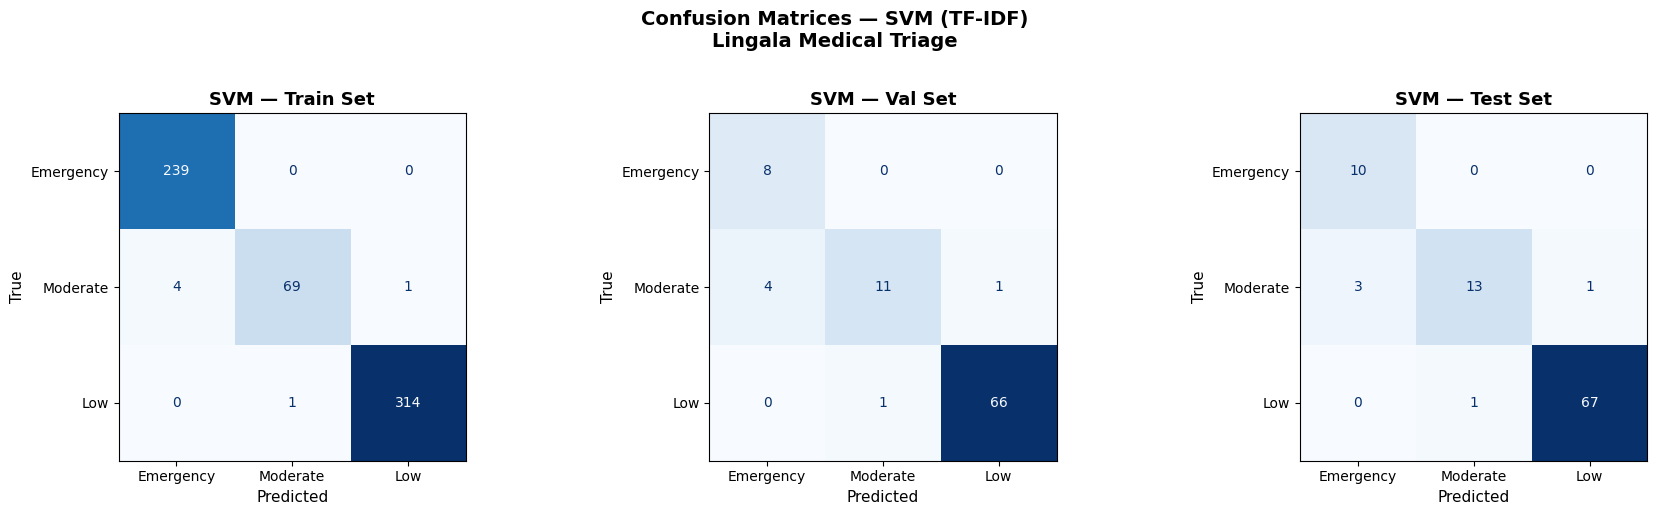

Saved → ./results/svm_confusion_matrices.png


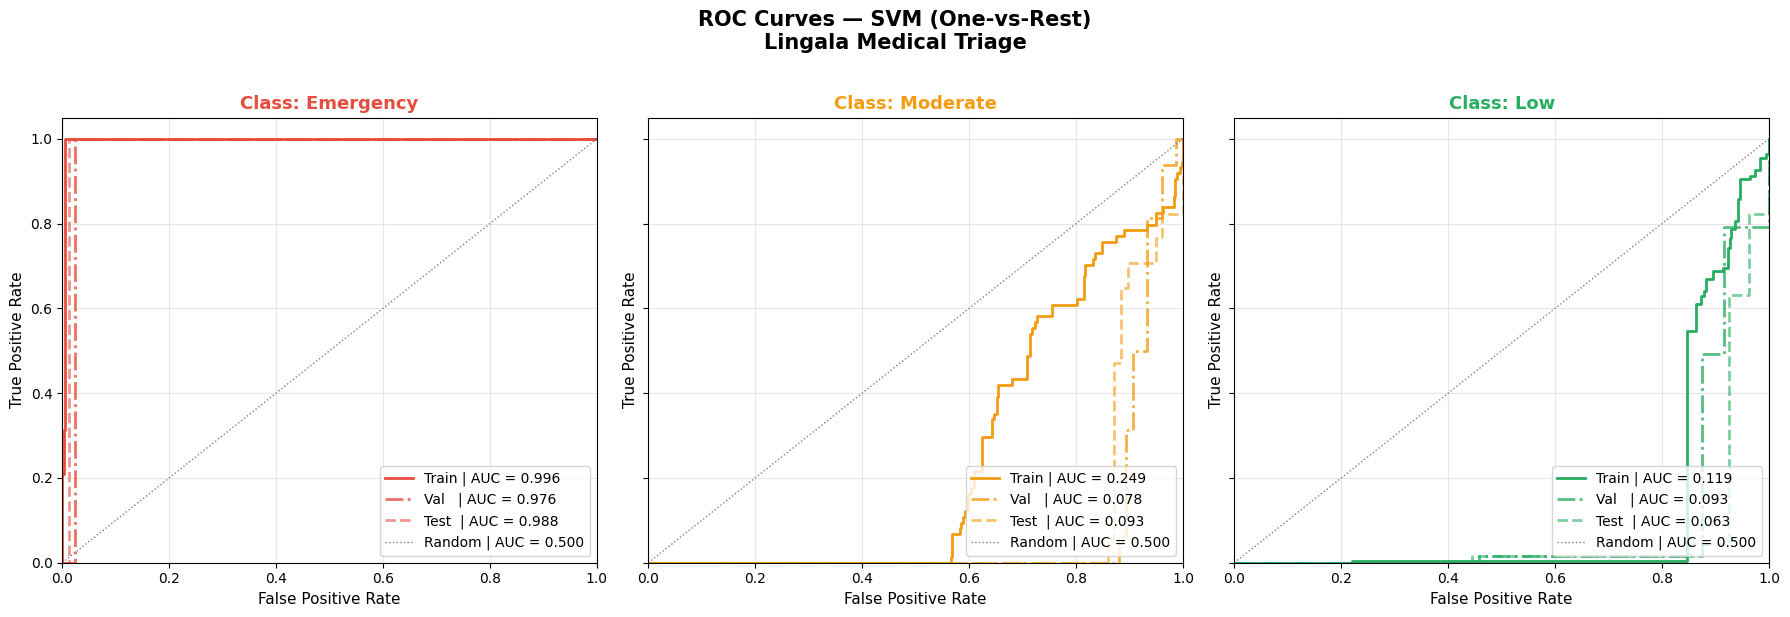

Saved → ./results/svm_roc_curves.png

── AUC Summary — SVM ────────────────────────────────────────
    Class  Train AUC  Val AUC  Test AUC
Emergency     0.9962   0.9759    0.9882
 Moderate     0.2492   0.0783    0.0928
      Low     0.1191   0.0927    0.0632

SVM + TF-IDF — Final Results
  Best C          : 2
  Train accuracy  : 99.04%
  Val   accuracy  : 93.41%
  Test  accuracy  : 94.74%
  Emergency AUC   : 0.988
  Moderate  AUC   : 0.093
  Low       AUC   : 0.063


In [45]:
# -------------------------------
# SVM with TF-IDF — Lingala Medical Triage
# -------------------------------

from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. TF-IDF vectorization
# -------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer

# Extract texts and labels
train_texts  = [s["text"]  for s in train_samples_aug]
train_labels = [s["label"] for s in train_samples_aug]

val_texts    = [s["text"]  for s in val_samples]
val_labels   = [s["label"] for s in val_samples]

test_texts   = [s["text"]  for s in test_samples]
test_labels  = [s["label"] for s in test_samples]

# Fit on augmented train, transform val and test
tfidf_vectorizer = TfidfVectorizer(
    max_features = 5000,
    stop_words   = list(STOPWORDS_MEDICAL)
)
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_val_tfidf   = tfidf_vectorizer.transform(val_texts)
X_test_tfidf  = tfidf_vectorizer.transform(test_texts)

print(f"Train shape : {X_train_tfidf.shape}")
print(f"Val shape   : {X_val_tfidf.shape}")
print(f"Test shape  : {X_test_tfidf.shape}")

# -------------------------------
# 2. Initialize SVM
# -------------------------------
supportvm = svm.SVC(random_state=42, probability=True)  # probability=True for ROC

# -------------------------------
# 3. Hyperparameter tuning
# -------------------------------
grid = GridSearchCV(
    supportvm,
    {"C": np.arange(1, 11, 1)},   # C from 1 to 10
    scoring = "f1_macro",          # macro-F1 more appropriate for imbalanced classes
    cv      = 5,
    n_jobs  = -1,
    verbose = 1,
)

# Fit on augmented train (post-augmentation)
grid.fit(X_train_tfidf, train_labels)
best_hyper = grid.best_params_
print(f"\nBest parameter C : {best_hyper['C']}")
print(f"Best CV score    : {grid.best_score_:.4f}")

# -------------------------------
# 4. Train SVM with best C
# -------------------------------
svm_tfidf = svm.SVC(
    C           = best_hyper["C"],
    random_state= 42,
    probability = True,            # needed for predict_proba (ROC curves)
    kernel      = "linear",        # linear works well for high-dim TF-IDF
)
svm_tfidf.fit(X_train_tfidf, train_labels)

# -------------------------------
# 5. Predict on train, val and test
# -------------------------------
y_train_pred = svm_tfidf.predict(X_train_tfidf)
y_val_pred   = svm_tfidf.predict(X_val_tfidf)
y_test_pred  = svm_tfidf.predict(X_test_tfidf)

# -------------------------------
# 6. Accuracy
# -------------------------------
train_acc = accuracy_score(train_labels, y_train_pred)
val_acc   = accuracy_score(val_labels,   y_val_pred)
test_acc  = accuracy_score(test_labels,  y_test_pred)

print(f"\nTrain accuracy : {train_acc:.2%}")
print(f"Val   accuracy : {val_acc:.2%}")
print(f"Test  accuracy : {test_acc:.2%}")

# -------------------------------
# 7. Classification report
# -------------------------------
class_names = ["Emergency", "Moderate", "Low"]

print("\n── Train Classification Report ──────────────────────────────")
print(classification_report(train_labels, y_train_pred,
                             target_names=class_names, zero_division=0))

print("── Val Classification Report ────────────────────────────────")
print(classification_report(val_labels, y_val_pred,
                             target_names=class_names, zero_division=0))

print("── Test Classification Report ───────────────────────────────")
print(classification_report(test_labels, y_test_pred,
                             target_names=class_names, zero_division=0))

# -------------------------------
# 8. Confusion matrices
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits = [
    ("Train", train_labels, y_train_pred),
    ("Val",   val_labels,   y_val_pred),
    ("Test",  test_labels,  y_test_pred),
]

for ax, (split, y_true, y_pred) in zip(axes, splits):
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"SVM — {split} Set", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)

plt.suptitle("Confusion Matrices — SVM (TF-IDF)\nLingala Medical Triage",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./results/svm_confusion_matrices.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved → ./results/svm_confusion_matrices.png")

# -------------------------------
# 9. ROC curves (one-vs-rest)
# -------------------------------
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

LABEL2ID = {"Emergency": 0, "Moderate": 1, "Low": 2}
unique_classes = np.array([0, 1, 2])

# Encode labels as integers
y_train_enc = np.array([LABEL2ID[l] for l in train_labels])
y_val_enc   = np.array([LABEL2ID[l] for l in val_labels])
y_test_enc  = np.array([LABEL2ID[l] for l in test_labels])

# Binarize
y_train_bin = label_binarize(y_train_enc, classes=unique_classes)
y_val_bin   = label_binarize(y_val_enc,   classes=unique_classes)
y_test_bin  = label_binarize(y_test_enc,  classes=unique_classes)

# Probabilities
scores_train = svm_tfidf.predict_proba(X_train_tfidf)
scores_val   = svm_tfidf.predict_proba(X_val_tfidf)
scores_test  = svm_tfidf.predict_proba(X_test_tfidf)

# Compute ROC / AUC per class
fpr_train, tpr_train, roc_auc_train = {}, {}, {}
fpr_val,   tpr_val,   roc_auc_val   = {}, {}, {}
fpr_test,  tpr_test,  roc_auc_test  = {}, {}, {}

for i in range(len(class_names)):
    fpr_train[i], tpr_train[i], _ = roc_curve(y_train_bin[:, i], scores_train[:, i])
    roc_auc_train[i] = auc(fpr_train[i], tpr_train[i])

    fpr_val[i],   tpr_val[i],   _ = roc_curve(y_val_bin[:, i],   scores_val[:, i])
    roc_auc_val[i]   = auc(fpr_val[i],   tpr_val[i])

    fpr_test[i],  tpr_test[i],  _ = roc_curve(y_test_bin[:, i],  scores_test[:, i])
    roc_auc_test[i]  = auc(fpr_test[i],  tpr_test[i])

# Plot
colors = {"Emergency": "#E74C3C", "Moderate": "#F39C12", "Low": "#27AE60"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (cname, ax) in enumerate(zip(class_names, axes)):
    color = colors[cname]
    ax.plot(fpr_train[i], tpr_train[i], color=color, linestyle="-",
            linewidth=2, label=f"Train | AUC = {roc_auc_train[i]:.3f}")
    ax.plot(fpr_val[i],   tpr_val[i],   color=color, linestyle="-.",
            linewidth=2, alpha=0.8, label=f"Val   | AUC = {roc_auc_val[i]:.3f}")
    ax.plot(fpr_test[i],  tpr_test[i],  color=color, linestyle="--",
            linewidth=2, alpha=0.6, label=f"Test  | AUC = {roc_auc_test[i]:.3f}")
    ax.plot([0,1], [0,1], color="gray", linestyle=":", linewidth=1,
            label="Random | AUC = 0.500")
    ax.set_title(f"Class: {cname}", fontsize=13,
                 fontweight="bold", color=color)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate",  fontsize=11)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(
    "ROC Curves — SVM (One-vs-Rest)\nLingala Medical Triage",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("./results/svm_roc_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved → ./results/svm_roc_curves.png")

# -------------------------------
# 10. AUC summary table
# -------------------------------
import pandas as pd

df_auc = pd.DataFrame({
    "Class":     class_names,
    "Train AUC": [round(roc_auc_train[i], 4) for i in range(3)],
    "Val AUC":   [round(roc_auc_val[i],   4) for i in range(3)],
    "Test AUC":  [round(roc_auc_test[i],  4) for i in range(3)],
})
print("\n── AUC Summary — SVM ────────────────────────────────────────")
print(df_auc.to_string(index=False))

# -------------------------------
# 11. Summary banner
# -------------------------------
print("\n" + "="*60)
print("SVM + TF-IDF — Final Results")
print("="*60)
print(f"  Best C          : {best_hyper['C']}")
print(f"  Train accuracy  : {train_acc:.2%}")
print(f"  Val   accuracy  : {val_acc:.2%}")
print(f"  Test  accuracy  : {test_acc:.2%}")
print(f"  Emergency AUC   : {roc_auc_test[0]:.3f}")
print(f"  Moderate  AUC   : {roc_auc_test[1]:.3f}")
print(f"  Low       AUC   : {roc_auc_test[2]:.3f}")
print("="*60)

### With SMOTE

Before SMOTE:
Low          315
Moderate      74
Emergency     41
Name: count, dtype: int64

Original train shape : (430, 175)

After SMOTE:
Low          315
Emergency    315
Moderate     315
Name: count, dtype: int64
SMOTE train shape : (945, 175)


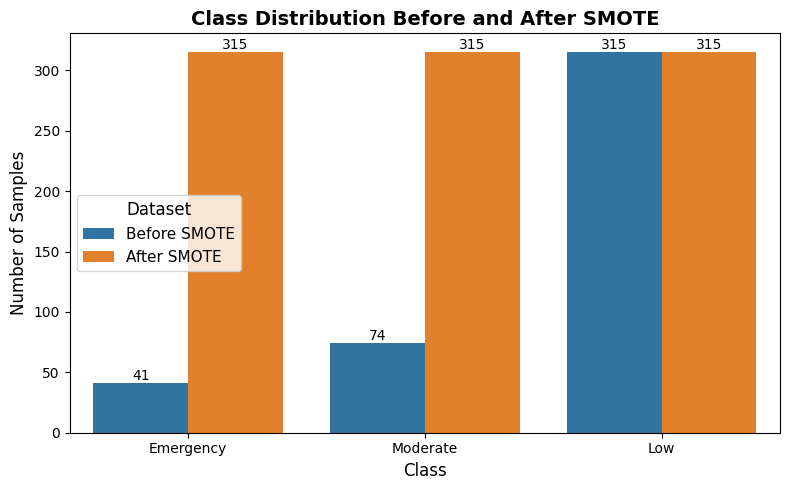

Saved → ./results/svm_smote_distribution.png
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameter C : 3
Best CV score    : 0.9989

Train accuracy (SMOTE) : 99.79%
Val   accuracy         : 93.41%
Test  accuracy         : 91.58%

── Train Classification Report (SMOTE) ──────────────────────
              precision    recall  f1-score   support

   Emergency       1.00      1.00      1.00       315
    Moderate       1.00      1.00      1.00       315
         Low       1.00      1.00      1.00       315

    accuracy                           1.00       945
   macro avg       1.00      1.00      1.00       945
weighted avg       1.00      1.00      1.00       945

── Val Classification Report ────────────────────────────────
              precision    recall  f1-score   support

   Emergency       0.70      0.88      0.78         8
    Moderate       0.99      0.99      0.99        67
         Low       0.86      0.75      0.80        16

    accuracy             

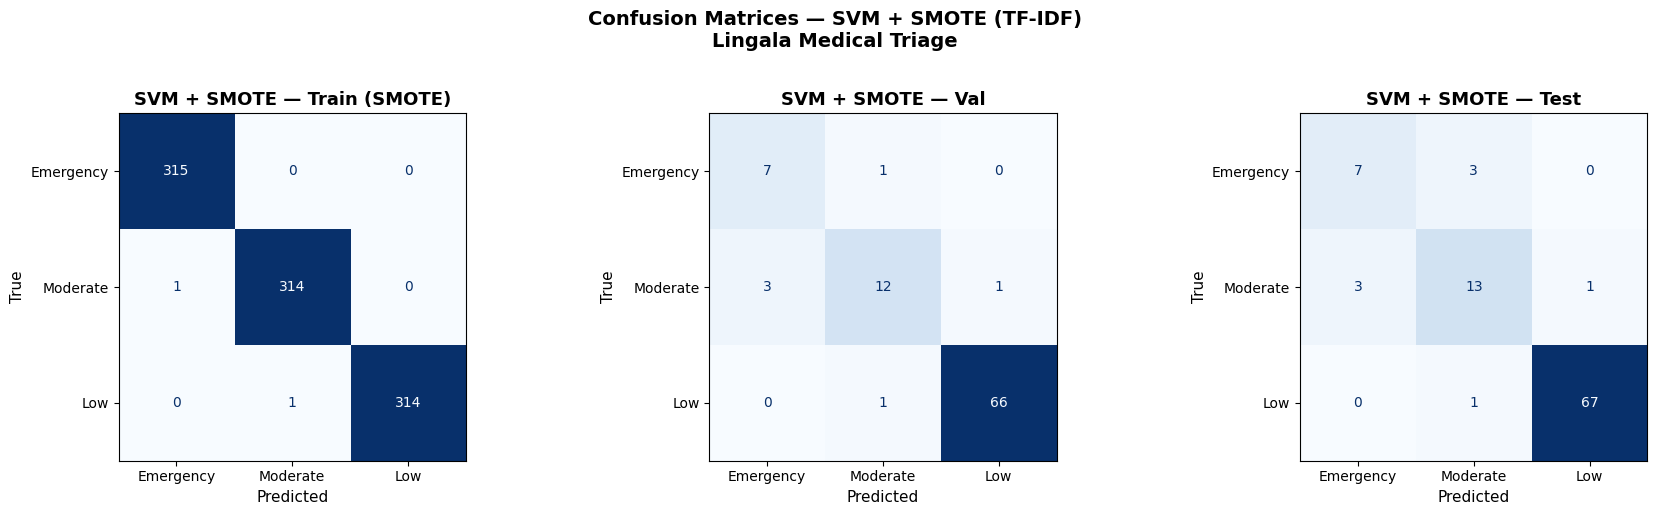

Saved → ./results/svm_smote_confusion_matrices.png


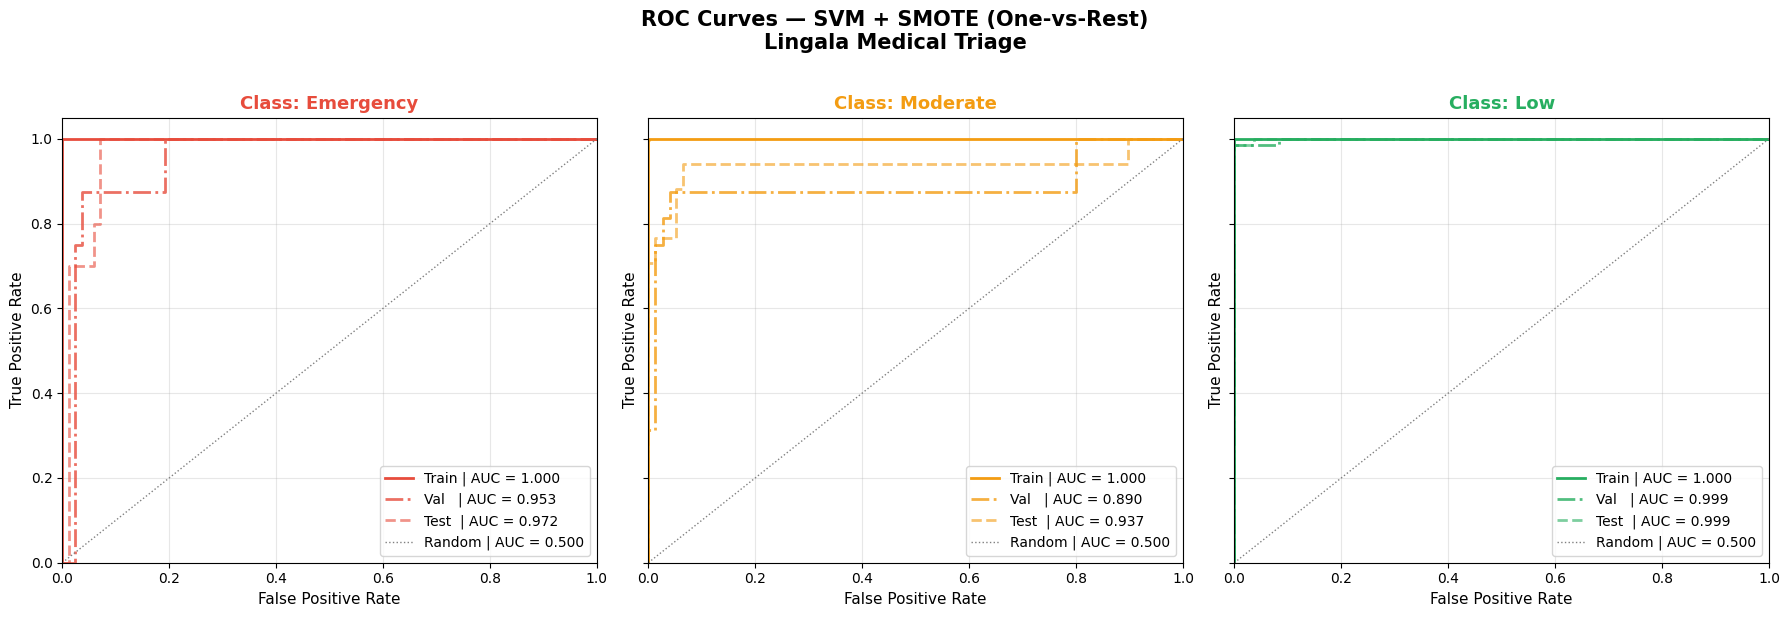

Saved → ./results/svm_smote_roc_curves.png

── AUC Summary — SVM + SMOTE ────────────────────────────────
    Class  Train AUC  Val AUC  Test AUC
Emergency        1.0   0.9533    0.9718
 Moderate        1.0   0.8900    0.9367
      Low        1.0   0.9988    0.9995

SVM + TF-IDF + SMOTE — Final Results
  Best C                  : 3
  Train accuracy (SMOTE)  : 99.79%
  Val   accuracy          : 93.41%
  Test  accuracy          : 91.58%
  Emergency Test AUC      : 0.972
  Moderate  Test AUC      : 0.937
  Low       Test AUC      : 0.999
  Mean      Test AUC      : 0.969


In [46]:
# -------------------------------
# SVM with TF-IDF + SMOTE — Lingala Medical Triage
# -------------------------------

from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Label mapping ─────────────────────────────────────────────────────────────
LABEL2ID    = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL    = {v: k for k, v in LABEL2ID.items()}
class_names = ["Emergency", "Moderate", "Low"]

# -------------------------------
# 1. Extract texts and labels
# -------------------------------
# Original train (pre-augmentation) → for SMOTE input
train_texts_orig  = [s["text"]  for s in train_samples]
train_labels_orig = [s["label"] for s in train_samples]
train_enc_orig    = [LABEL2ID[l] for l in train_labels_orig]

# Val and Test — never resampled
val_texts    = [s["text"]  for s in val_samples]
val_labels   = [s["label"] for s in val_samples]
val_enc      = [LABEL2ID[l] for l in val_labels]

test_texts   = [s["text"]  for s in test_samples]
test_labels  = [s["label"] for s in test_samples]
test_enc     = [LABEL2ID[l] for l in test_labels]

print("Before SMOTE:")
print(pd.Series(train_enc_orig).map(ID2LABEL).value_counts())

# -------------------------------
# 2. TF-IDF vectorization
# -------------------------------
tfidf_vectorizer = TfidfVectorizer(
    max_features = 5000,
    stop_words   = list(STOPWORDS_MEDICAL)
)

# Fit on original train, transform val and test
X_train_orig = tfidf_vectorizer.fit_transform(train_texts_orig)
X_val_tfidf  = tfidf_vectorizer.transform(val_texts)
X_test_tfidf = tfidf_vectorizer.transform(test_texts)

print(f"\nOriginal train shape : {X_train_orig.shape}")

# -------------------------------
# 3. Apply SMOTE
# -------------------------------
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_orig, train_enc_orig
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).map(ID2LABEL).value_counts())
print(f"SMOTE train shape : {X_train_smote.shape}")

# -------------------------------
# 4. Plot before / after SMOTE
# -------------------------------
y_before_str = pd.Series(train_enc_orig).map(ID2LABEL)
y_after_str  = pd.Series(y_train_smote).map(ID2LABEL)

df_before = pd.DataFrame({"Classe":  y_before_str,
                           "Dataset": "Before SMOTE"})
df_after  = pd.DataFrame({"Classe":  y_after_str,
                           "Dataset": "After SMOTE"})
df_plot   = pd.concat([df_before, df_after], axis=0)

import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_plot, x="Classe", hue="Dataset",
              order=class_names,
              palette={"Before SMOTE": "#1f77b4",
                       "After SMOTE":  "#ff7f0e"},
              ax=ax)
ax.set_title("Class Distribution Before and After SMOTE",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Class",             fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.legend(title="Dataset", fontsize=11, title_fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("./results/svm_smote_distribution.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved → ./results/svm_smote_distribution.png")

# -------------------------------
# 5. Initialize SVM
# -------------------------------
supportvm = svm.SVC(random_state=42, probability=True)

# -------------------------------
# 6. Hyperparameter tuning on SMOTE data
# -------------------------------
grid = GridSearchCV(
    supportvm,
    {"C": np.arange(1, 11, 1)},
    scoring = "f1_macro",
    cv      = 5,
    n_jobs  = -1,
    verbose = 1,
)

grid.fit(X_train_smote, y_train_smote)
best_hyper = grid.best_params_
print(f"\nBest parameter C : {best_hyper['C']}")
print(f"Best CV score    : {grid.best_score_:.4f}")

# -------------------------------
# 7. Train SVM with best C on SMOTE data
# -------------------------------
svm_smote = svm.SVC(
    C            = best_hyper["C"],
    random_state = 42,
    probability  = True,
    kernel       = "linear",
)
svm_smote.fit(X_train_smote, y_train_smote)

# -------------------------------
# 8. Predict on train (SMOTE), val and test
# -------------------------------
y_train_pred = svm_smote.predict(X_train_smote)
y_val_pred   = svm_smote.predict(X_val_tfidf)
y_test_pred  = svm_smote.predict(X_test_tfidf)

# Decode predictions back to string labels for report
y_train_pred_str = [ID2LABEL[p] for p in y_train_pred]
y_val_pred_str   = [ID2LABEL[p] for p in y_val_pred]
y_test_pred_str  = [ID2LABEL[p] for p in y_test_pred]

# -------------------------------
# 9. Accuracy
# -------------------------------
train_acc = accuracy_score(y_train_smote, y_train_pred)
val_acc   = accuracy_score(val_enc,       y_val_pred)
test_acc  = accuracy_score(test_enc,      y_test_pred)

print(f"\nTrain accuracy (SMOTE) : {train_acc:.2%}")
print(f"Val   accuracy         : {val_acc:.2%}")
print(f"Test  accuracy         : {test_acc:.2%}")

# -------------------------------
# 10. Classification reports
# -------------------------------
print("\n── Train Classification Report (SMOTE) ──────────────────────")
print(classification_report(
    [ID2LABEL[l] for l in y_train_smote], y_train_pred_str,
    target_names=class_names, zero_division=0
))

print("── Val Classification Report ────────────────────────────────")
print(classification_report(
    val_labels, y_val_pred_str,
    target_names=class_names, zero_division=0
))

print("── Test Classification Report ───────────────────────────────")
print(classification_report(
    test_labels, y_test_pred_str,
    target_names=class_names, zero_division=0
))

# -------------------------------
# 11. Confusion matrices
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits = [
    ("Train (SMOTE)", [ID2LABEL[l] for l in y_train_smote], y_train_pred_str),
    ("Val",           val_labels,                            y_val_pred_str),
    ("Test",          test_labels,                           y_test_pred_str),
]

for ax, (split, y_true, y_pred) in zip(axes, splits):
    cm   = confusion_matrix(y_true, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"SVM + SMOTE — {split}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)

plt.suptitle("Confusion Matrices — SVM + SMOTE (TF-IDF)\nLingala Medical Triage",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./results/svm_smote_confusion_matrices.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved → ./results/svm_smote_confusion_matrices.png")

# -------------------------------
# 12. ROC curves (one-vs-rest)
# -------------------------------
unique_classes = np.array([0, 1, 2])

# Binarize
y_train_bin = label_binarize(y_train_smote, classes=unique_classes)
y_val_bin   = label_binarize(val_enc,        classes=unique_classes)
y_test_bin  = label_binarize(test_enc,       classes=unique_classes)

# Probabilities
scores_train = svm_smote.predict_proba(X_train_smote)
scores_val   = svm_smote.predict_proba(X_val_tfidf)
scores_test  = svm_smote.predict_proba(X_test_tfidf)

# ROC / AUC per class
fpr_train, tpr_train, roc_auc_train = {}, {}, {}
fpr_val,   tpr_val,   roc_auc_val   = {}, {}, {}
fpr_test,  tpr_test,  roc_auc_test  = {}, {}, {}

for i in range(len(class_names)):
    fpr_train[i], tpr_train[i], _ = roc_curve(y_train_bin[:, i], scores_train[:, i])
    roc_auc_train[i] = auc(fpr_train[i], tpr_train[i])

    fpr_val[i],   tpr_val[i],   _ = roc_curve(y_val_bin[:, i],   scores_val[:, i])
    roc_auc_val[i]   = auc(fpr_val[i],   tpr_val[i])

    fpr_test[i],  tpr_test[i],  _ = roc_curve(y_test_bin[:, i],  scores_test[:, i])
    roc_auc_test[i]  = auc(fpr_test[i],  tpr_test[i])

# Plot
colors = {"Emergency": "#E74C3C", "Moderate": "#F39C12", "Low": "#27AE60"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (cname, ax) in enumerate(zip(class_names, axes)):
    color = colors[cname]
    ax.plot(fpr_train[i], tpr_train[i], color=color, linestyle="-",
            linewidth=2, label=f"Train | AUC = {roc_auc_train[i]:.3f}")
    ax.plot(fpr_val[i],   tpr_val[i],   color=color, linestyle="-.",
            linewidth=2, alpha=0.8, label=f"Val   | AUC = {roc_auc_val[i]:.3f}")
    ax.plot(fpr_test[i],  tpr_test[i],  color=color, linestyle="--",
            linewidth=2, alpha=0.6, label=f"Test  | AUC = {roc_auc_test[i]:.3f}")
    ax.plot([0,1],[0,1], color="gray", linestyle=":", linewidth=1,
            label="Random | AUC = 0.500")
    ax.set_title(f"Class: {cname}", fontsize=13,
                 fontweight="bold", color=color)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate",  fontsize=11)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(
    "ROC Curves — SVM + SMOTE (One-vs-Rest)\nLingala Medical Triage",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("./results/svm_smote_roc_curves.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved → ./results/svm_smote_roc_curves.png")

# -------------------------------
# 13. AUC summary table
# -------------------------------
df_auc = pd.DataFrame({
    "Class":     class_names,
    "Train AUC": [round(roc_auc_train[i], 4) for i in range(3)],
    "Val AUC":   [round(roc_auc_val[i],   4) for i in range(3)],
    "Test AUC":  [round(roc_auc_test[i],  4) for i in range(3)],
})
print("\n── AUC Summary — SVM + SMOTE ────────────────────────────────")
print(df_auc.to_string(index=False))

# -------------------------------
# 14. Summary banner
# -------------------------------
print("\n" + "="*60)
print("SVM + TF-IDF + SMOTE — Final Results")
print("="*60)
print(f"  Best C                  : {best_hyper['C']}")
print(f"  Train accuracy (SMOTE)  : {train_acc:.2%}")
print(f"  Val   accuracy          : {val_acc:.2%}")
print(f"  Test  accuracy          : {test_acc:.2%}")
print(f"  Emergency Test AUC      : {roc_auc_test[0]:.3f}")
print(f"  Moderate  Test AUC      : {roc_auc_test[1]:.3f}")
print(f"  Low       Test AUC      : {roc_auc_test[2]:.3f}")
print(f"  Mean      Test AUC      : {np.mean([roc_auc_test[i] for i in range(3)]):.3f}")
print("="*60)

### Train the DL Model

In [22]:
vocab_size = 500 # Number of words you want to tokenize i.e maximum number of words to keep
embeding_dim = 16
drop_value = 0.2 # dropout
n_dense = 24

In [23]:
from keras.layers import *
from keras.models import *
from keras import backend as K

### Defining the attention class.

In [25]:
from tensorflow import keras
from tensorflow.keras.layers import Layer, Dense, Activation
from tensorflow.keras import initializers

class attention(Layer):
    def __init__(self, return_sequences=True,**kwargs):
        # Add the keyword argument to super().__init__
        super(attention, self).__init__(**kwargs)
        self.return_sequences = return_sequences
        self.W = None
        self.b = None
        self.u = None

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], input_shape[-1]),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[-1],),
                                 initializer="zeros")
        self.u = self.add_weight(name="att_context_vector", shape=(input_shape[-1], 1),
                                 initializer="normal")
        super(attention, self).build(input_shape)

    def call(self, x):
        # Alignment scores. Pass them through tanh function
        ui = keras.activations.tanh(keras.backend.dot(x, self.W) + self.b)

        # Remove dimension of size 1
        ai = keras.backend.dot(ui, self.u)[:, :, 0]

        # Apply softmax to get attention weights and then
        # multiply them with the input sequence
        ai = keras.activations.softmax(ai, axis=1)
        weighted_input = x * keras.backend.expand_dims(ai, axis=2)

        if self.return_sequences:
            return weighted_input
        else:
            return keras.backend.sum(weighted_input, axis=1)

    def compute_output_shape(self, input_shape):
        """
        For Keras internal compatibility checking
        """
        if self.return_sequences:
            return input_shape
        else:
            return input_shape[0], input_shape[-1]

    def get_config(self):
        """
        For saving and loading model with custom layer
        """
        config = super().get_config().copy()
        config.update({'return_sequences': self.return_sequences})
        return config

Here I have defined a class called attention in which I have defined two functions. Let’s see what these functions will do for the mechanism.

In [26]:
def build(self, input_shape):
        self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],1),
                               initializer="normal")
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],1),
                               initializer="zeros")

In [50]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

class attention(tf.keras.layers.Layer):  # Inherit from tf.keras.layers.Layer
    def __init__(self, return_sequences=True, **kwargs): # Add return_sequences to __init__
        self.return_sequences = return_sequences  # Store return_sequences as an attribute
        super(attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],1),
                               initializer="normal")
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],1),
                               initializer="normal")
        super(attention, self).build(input_shape)

    def call(self, x):
        # Alignment scores. Pass them through tanh function
        e = tf.keras.activations.tanh(tf.keras.backend.dot(x,self.W)+self.b)
        # Remove dimension of size 1
        e = tf.keras.backend.squeeze(e, axis=-1)
        # Compute the weights
        alpha = tf.keras.activations.softmax(e)
        # Reshape to tensorFlow format
        alpha = tf.keras.backend.expand_dims(alpha, axis=-1)
        # Compute the context vector
        context = x * alpha
        # Return sequences or context vector based on return_sequences
        if self.return_sequences:
            return context
        else:
            return tf.keras.backend.sum(context, axis=1)


    # Add compute_output_shape for TensorFlow 2.x compatibility
    def compute_output_shape(self, input_shape):
        if self.return_sequences:
            return input_shape
        return (input_shape[0], input_shape[-1]) # Shape if not returning sequences


Here we can see that we have given an attention layer to the model. Let’s check for the results.

In [33]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM,
                                     Dropout, Dense, Layer, Input)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TF version:", tf.__version__)

# ══════════════════════════════════════════════════════════════════════════════
# 1. PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════
vocab_size   = 5000
embeding_dim = 128
max_len      = 128
NUM_CLASSES  = 3
BATCH_SIZE   = 32
LABEL2ID     = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL     = {v: k for k, v in LABEL2ID.items()}

# ══════════════════════════════════════════════════════════════════════════════
# 2. EXTRACT TEXTS AND LABELS
# ══════════════════════════════════════════════════════════════════════════════
train_texts_aug  = [s["text"]  for s in train_samples_aug]
train_labels_aug = [s["label"] for s in train_samples_aug]

val_texts_list   = [s["text"]  for s in val_samples]
val_labels_list  = [s["label"] for s in val_samples]

test_texts_list  = [s["text"]  for s in test_samples]
test_labels_list = [s["label"] for s in test_samples]

print(f"Train: {len(train_texts_aug)} | Val: {len(val_texts_list)} | Test: {len(test_texts_list)}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. TOKENIZATION AND PADDING
# ══════════════════════════════════════════════════════════════════════════════
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts_aug)

train_pad_arr = pad_sequences(tokenizer.texts_to_sequences(train_texts_aug),
                               maxlen=max_len, padding="post", truncating="post")
val_pad_arr   = pad_sequences(tokenizer.texts_to_sequences(val_texts_list),
                               maxlen=max_len, padding="post", truncating="post")
test_pad_arr  = pad_sequences(tokenizer.texts_to_sequences(test_texts_list),
                               maxlen=max_len, padding="post", truncating="post")

# ══════════════════════════════════════════════════════════════════════════════
# 4. ENCODE LABELS
# ══════════════════════════════════════════════════════════════════════════════
train_labels_enc = np.array([LABEL2ID[l] for l in train_labels_aug])
val_labels_enc   = np.array([LABEL2ID[l] for l in val_labels_list])
test_labels_enc  = np.array([LABEL2ID[l] for l in test_labels_list])

assert train_pad_arr.shape[0] == train_labels_enc.shape[0]
assert val_pad_arr.shape[0]   == val_labels_enc.shape[0]
assert test_pad_arr.shape[0]  == test_labels_enc.shape[0]

print(f"train: {train_pad_arr.shape} labels: {train_labels_enc.shape}")
print(f"val  : {val_pad_arr.shape}   labels: {val_labels_enc.shape}")
print(f"test : {test_pad_arr.shape}  labels: {test_labels_enc.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# 5. CONVERT TO TF TENSORS
# ══════════════════════════════════════════════════════════════════════════════
train_pad_tf    = tf.cast(tf.constant(train_pad_arr),    dtype=tf.int32)
train_labels_tf = tf.cast(tf.constant(train_labels_enc), dtype=tf.int32)
val_pad_tf      = tf.cast(tf.constant(val_pad_arr),      dtype=tf.int32)
val_labels_tf   = tf.cast(tf.constant(val_labels_enc),   dtype=tf.int32)
test_pad_tf     = tf.cast(tf.constant(test_pad_arr),     dtype=tf.int32)
test_labels_tf  = tf.cast(tf.constant(test_labels_enc),  dtype=tf.int32)

# ══════════════════════════════════════════════════════════════════════════════
# 6. ATTENTION LAYER
# ══════════════════════════════════════════════════════════════════════════════
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name        = "att_W",
            shape       = (input_shape[-1], 1),
            initializer = "glorot_uniform",
            trainable   = True
        )
        self.built = True

    def call(self, x):
        score = K.tanh(K.dot(x, self.W))   # (batch, timesteps, 1)
        alpha = K.softmax(score, axis=1)    # (batch, timesteps, 1)
        return K.sum(x * alpha, axis=1)     # (batch, features)

    def get_config(self):
        return super().get_config()

# ══════════════════════════════════════════════════════════════════════════════
# 7. BUILD MODEL
# ══════════════════════════════════════════════════════════════════════════════
inputs  = Input(shape=(max_len,), name="input")
x       = Embedding(vocab_size, embeding_dim, name="embed")(inputs)
x       = Bidirectional(LSTM(64, return_sequences=True), name="bilstm")(x)
x       = Dropout(0.5, name="dropout")(x)
x       = AttentionLayer(name="attention")(x)
outputs = Dense(NUM_CLASSES, activation="softmax", name="output")(x)

model2_b = Model(inputs, outputs, name="BiLSTM_Attention_3class")

model2_b.compile(
    loss      = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics   = ["accuracy"]   # ← AUC removed — computed manually after training
)

# ── Verify ────────────────────────────────────────────────────────────────────
dummy = np.zeros((2, max_len), dtype="int32")
out   = model2_b(dummy)
print(f"\nOutput shape : {out.shape}")              # (2, 3)
print(f"Output sums  : {out.numpy().sum(axis=1)}")  # ~[1.0, 1.0]
model2_b.summary()

# ══════════════════════════════════════════════════════════════════════════════
# 8. TRAIN
# ══════════════════════════════════════════════════════════════════════════════
early_stop = EarlyStopping(
    monitor              = "val_loss",
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1
)

history_biatt = model2_b.fit(
    train_pad_tf,
    train_labels_tf,
    epochs          = 100,
    validation_data = (val_pad_tf, val_labels_tf),
    callbacks       = [early_stop],
    batch_size      = BATCH_SIZE,
    verbose         = 2
)

print("\nFirst 5 loss:", history_biatt.history["loss"][:5])

# ══════════════════════════════════════════════════════════════════════════════
# 9. EVALUATE ON TEST SET
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

test_probs     = model2_b.predict(test_pad_tf)
test_preds     = np.argmax(test_probs, axis=1)
test_preds_str = [ID2LABEL[p] for p in test_preds]

# ── Classification report ─────────────────────────────────────────────────────
print("\n── Test Classification Report ───────────────────────────────")
print(classification_report(test_labels_list, test_preds_str,
      target_names=["Emergency", "Moderate", "Low"], zero_division=0))

# ── Macro AUC (computed via sklearn) ─────────────────────────────────────────
y_test_bin = label_binarize(test_labels_enc, classes=[0, 1, 2])
macro_auc  = roc_auc_score(y_test_bin, test_probs,
                            multi_class="ovr", average="macro")
print(f"Test Macro AUC (sklearn): {macro_auc:.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm   = confusion_matrix(test_labels_list, test_preds_str,
                        labels=["Emergency", "Moderate", "Low"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Emergency", "Moderate", "Low"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("BiLSTM + Attention — Test Confusion Matrix",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("./results/bilstm_attention_confusion.png",
            bbox_inches="tight", dpi=150)
plt.show()

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
metrics   = [("loss",     "Loss",     "#E74C3C"),
             ("accuracy", "Accuracy", "#27AE60")]

for ax, (metric, title, color) in zip(axes, metrics):
    ax.plot(history_biatt.history[metric],
            color=color, linewidth=2, label="Train")
    ax.plot(history_biatt.history[f"val_{metric}"],
            color=color, linewidth=2, linestyle="--",
            alpha=0.7, label="Val")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel(title,   fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle("Training Curves — BiLSTM + Attention\nLingala Medical Triage",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./results/bilstm_attention_training_curves.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved → ./results/bilstm_attention_training_curves.png")

TF version: 2.20.0
Train: 625 | Val: 91 | Test: 95
train: (625, 128) labels: (625,)
val  : (91, 128)   labels: (91,)
test : (95, 128)  labels: (95,)

Output shape : (2, 3)
Output sums  : [1. 1.]


Model: "BiLSTM_Attention_3class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed (Embedding)               │ (None, 128, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,331 (2.82 MB)

 Trainable params: 739,331 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 - 2s - 113ms/step - accuracy: 0.4848 - loss: 0.9874 - val_accuracy: 0.7363 - val_loss: 0.9395
Epoch 2/100
20/20 - 1s - 28ms/step - accuracy: 0.4976 - loss: 0.9639 - val_accuracy: 0.7363 - val_loss: 0.8470
Epoch 3/100
20/20 - 1s - 28ms/step - accuracy: 0.5088 - loss: 0.9375 - val_accuracy: 0.7363 - val_loss: 0.8089
Epoch 4/100
20/20 - 1s - 28ms/step - accuracy: 0.7568 - loss: 0.6906 - val_accuracy: 0.8022 - val_loss: 0.5814
Epoch 5/100
20/20 - 1s - 28ms/step - accuracy: 0.8640 - loss: 0.4051 - val_accuracy: 0.8022 - val_loss: 0.4375
Epoch 6/100
20/20 - 1s - 30ms/step - accuracy: 0.8720 - loss: 0.3033 - val_accuracy: 0.8022 - val_loss: 0.3463
Epoch 7/100
20/20 - 1s - 29ms/step - accuracy: 0.8832 - loss: 0.2652 - val_accuracy: 0.8242 - val_loss: 0.2869
Epoch 8/100
20/20 - 1s - 31ms/step - accuracy: 0.8944 - loss: 0.2268 - val_accuracy: 0.8242 - val_loss: 0.2666
Epoch 9/100
20/20 - 1s - 29ms/step - accuracy: 0.9424 - loss: 0.1788 - val_accuracy: 0.9341 - val_loss: 0.2308


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# HYBRID TRIAGE MODEL (Trainable)
# ─────────────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel  # <-- keep only these from transformers
from torch.optim import AdamW  # <-- move AdamW here
import numpy as np

LABEL2ID = {"Emergency": 0, "Moderate": 1, "Low": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

# ─────────────────────────────────────────────────────────────────────────────
# Dataset Class
# ─────────────────────────────────────────────────────────────────────────────
class TriageDataset(Dataset):
    def __init__(self, samples, tokenizer, max_length=128):
        self.samples = samples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        text = self.samples[idx]["text"]
        label = LABEL2ID[self.samples[idx]["label"]]
        enc = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

# ─────────────────────────────────────────────────────────────────────────────
# Hybrid Model
# ─────────────────────────────────────────────────────────────────────────────
class HybridTriageModel(nn.Module):
    def __init__(self, backbone="afroxlmr", device=None):
        super().__init__()
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.backbone_name = backbone
        if backbone == "afroxlmr":
            self.model_name = "castorini/afrixlmr-large"  # replace with actual model repo
        elif backbone == "afriteva":
            self.model_name = "afriteva/afriteva-large"   # replace with actual model repo
        else:
            raise ValueError("Backbone must be 'afroxlmr' or 'afriteva'")

        print(f"Loading {self.backbone_name} model...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.encoder = AutoModel.from_pretrained(self.model_name)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, len(LABEL2ID))
        self.to(self.device)

    # ── Forward Pass
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]  # [CLS] token
        logits = self.classifier(pooled)
        return logits

    # ── Train Loop
    def train(self, train_samples, val_samples, epochs=5, batch_size=16, learning_rate=2e-5, class_weights=None):
        train_dataset = TriageDataset(train_samples, self.tokenizer)
        val_dataset = TriageDataset(val_samples, self.tokenizer)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        self.train()  # set model to training mode
        optimizer = AdamW(self.parameters(), lr=learning_rate)
        if class_weights is not None:
            weights = torch.tensor(class_weights, dtype=torch.float).to(self.device)
            criterion = nn.CrossEntropyLoss(weight=weights)
        else:
            criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            total_loss = 0
            for batch in train_loader:
                optimizer.zero_grad()
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["label"].to(self.device)

                logits = self.forward(input_ids, attention_mask)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}")

    # ── Evaluation
    def evaluate(self, test_samples):
        self.eval()
        test_dataset = TriageDataset(test_samples, self.tokenizer)
        test_loader = DataLoader(test_dataset, batch_size=16)
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["label"].to(self.device)

                logits = self.forward(input_ids, attention_mask)
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Compute metrics
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        accuracy = (all_preds == all_labels).mean()
        macro_f1 = np.mean([f1_score(all_labels==i, all_preds==i) for i in range(len(LABEL2ID))])
        emergency_recall = (all_preds[all_labels==0] == 0).sum() / max(1, (all_labels==0).sum())
        critical_error_rate = ((all_preds[all_labels==0] != 0) & (all_preds[all_labels==0] != 1)).sum() / max(1, (all_labels==0).sum())
        cm = confusion_matrix(all_labels, all_preds)

        return {
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "emergency_recall": emergency_recall,
            "critical_error_rate": critical_error_rate,
            "confusion_matrix": cm.tolist()
        }

    # ── Save Model
    def save(self, path):
        os.makedirs(path, exist_ok=True)
        torch.save(self.state_dict(), os.path.join(path, "hybrid_model.pt"))
        print(f"Hybrid model saved to {path}")